# EDA

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

## Subreddit-1: learnprogramming

### Part-1: Data Overview

In [126]:
DATA_DIR = '/Users/yangshuting/Desktop/UChicago/courses/spring_2026/MACS_30200_Research_Design/final_proposal/data/raw_data/learnprogramming/'
POSTS_PATH    = DATA_DIR + 'r_learnprogramming_posts.jsonl'
COMMENTS_PATH = DATA_DIR + 'r_learnprogramming_comments.jsonl'
OBS_END = pd.Timestamp('2026-01-01', tz='UTC')

In [127]:
# load posts - keep only needed columns
POSTS_COLS = ['author', 'created_utc', 'id', 'title', 'selftext', 'score', 'num_comments']

posts = []
with open(POSTS_PATH) as f:
    for line in f:
        d = json.loads(line)
        posts.append({k: d.get(k) for k in POSTS_COLS})

posts_lp = pd.DataFrame(posts)
posts_lp.shape

(640028, 7)

In [128]:
# load comments - keep only needed columns
COMMENTS_COLS = ['author', 'created_utc', 'id', 'body', 'score', 'parent_id', 'link_id']

comments = []
with open(COMMENTS_PATH) as f:
    for line in f:
        d = json.loads(line)
        comments.append({k: d.get(k) for k in COMMENTS_COLS})

comments_lp = pd.DataFrame(comments)
comments_lp.shape

(4464776, 7)

In [129]:
# get an overview of posts
posts_lp.head()

,author,created_utc,id,title,selftext,score,num_comments
0,6553321,1253766972,9njl7,Welcome everyone.,In honor of http://www.reddit.com/r/programmin...,12,11
1,6553321,1253772944,9nkb7,Keywords to save you a Google,Trying to collect keywords that may be thrown ...,8,11
2,6553321,1253775523,9nkok,C how to program,,11,13
3,lolinyerface,1253795135,9nn5f,Interested in learning Python?,,19,14
4,Dman003,1253951269,9o9g0,Does using code snippets when programming help?,,8,5


In [130]:
# get an overview of comments
comments_lp.head()

,author,created_utc,id,body,score,parent_id,link_id
0,6553321,1253767158,c0divrv,For starters we can have basic learn <language...,1,t3_9njl7,t3_9njl7
1,sutcivni,1253769598,c0dix96,The question is how are we going to distinguis...,2,t1_c0divrv,t3_9njl7
2,6553321,1253772781,c0diyv9,I don't think there is a real need to but we'l...,1,t1_c0dix96,t3_9njl7
3,WebDevWannaBe,1253774613,c0dizo3,my repost from the other thread: (just let me ...,2,t3_9njl7,t3_9njl7
4,6553321,1253775120,c0dizwp,Compiler: A tool that takes a program written ...,7,t3_9nkb7,t3_9nkb7


In [131]:
# check data types
posts_lp.dtypes

author          object
created_utc      int64
id              object
title           object
selftext        object
score            int64
num_comments     int64
dtype: object

### Part-2: Data Cleaning

#### 2.1 Remove missing values

In [132]:
# check missing values
null_posts    = posts_lp.isnull().sum()
null_comments = comments_lp.isnull().sum()
print('=== Posts ===')
print(null_posts)
print('\n=== Comments ===')
print(null_comments)

=== Posts ===
author          0
created_utc     0
id              0
title           0
selftext        0
score           0
num_comments    0
dtype: int64

=== Comments ===
author         0
created_utc    0
id             0
body           0
score          0
parent_id      0
link_id        0
dtype: int64


In [133]:
# drop columns that have at least 30% missing values
posts_lp.drop(columns=posts_lp.columns[null_posts > len(posts_lp) * 0.3], inplace=True)
comments_lp.drop(columns=comments_lp.columns[null_comments > len(comments_lp) * 0.3], inplace=True)

# check remaining columns
print('posts columns:', posts_lp.columns.tolist())
print('comments columns:', comments_lp.columns.tolist())

posts columns: ['author', 'created_utc', 'id', 'title', 'selftext', 'score', 'num_comments']
comments columns: ['author', 'created_utc', 'id', 'body', 'score', 'parent_id', 'link_id']


All selected columns show zero missing values. This is expected because I only loaded the core fields that Reddit's data schema always populates (such as `author`, `created_utc`, and `id`). The Arctic Shift archive stores only complete records, so entries with missing mandatory fields are excluded at the data collection stage.

#### 2.2 Remove duplicates

In [134]:
# check duplicate content: same user posting identical text
# posts: same author + same title; 
# comments: same author + same body
dup_posts    = posts_lp.duplicated(subset=['author', 'title'], keep=False).sum()
dup_comments = comments_lp.duplicated(subset=['author', 'body'], keep=False).sum()

print(f'duplicate posts (same author + title):   {dup_posts:,}')
print(f'duplicate comments (same author + body): {dup_comments:,}')

duplicate posts (same author + title):   18,233
duplicate comments (same author + body): 346,508


In [135]:
# drop duplicates, keep first occurrence
posts_lp    = posts_lp.drop_duplicates(subset=['author', 'title'], keep='first').reset_index(drop=True)
comments_lp = comments_lp.drop_duplicates(subset=['author', 'body'],  keep='first').reset_index(drop=True)

n_posts_after_dedup    = len(posts_lp)
n_comments_after_dedup = len(comments_lp)
print(f'posts after dedup:    {n_posts_after_dedup:,}')
print(f'comments after dedup: {n_comments_after_dedup:,}')

posts after dedup:    627,004
comments after dedup: 4,133,442


#### 2.3 Remove user-deleted accounts

In [136]:
# check [deleted] author proportion
print('=== Posts ===')
print(f'total: {len(posts_lp):,}')
print(f'[deleted]: {(posts_lp["author"] == "[deleted]").sum():,}  ({(posts_lp["author"] == "[deleted]").mean()*100:.1f}%)')
print(f'[removed]: {(posts_lp["author"] == "[removed]").sum():,}')

print('\n=== Comments ===')
print(f'total: {len(comments_lp):,}')
print(f'[deleted]: {(comments_lp["author"] == "[deleted]").sum():,}  ({(comments_lp["author"] == "[deleted]").mean()*100:.1f}%)')
print(f'[removed]: {(comments_lp["author"] == "[removed]").sum():,}')

=== Posts ===
total: 627,004
[deleted]: 109,566  (17.5%)
[removed]: 0

=== Comments ===
total: 4,133,442
[deleted]: 107,076  (2.6%)
[removed]: 0


Each Reddit record has two distinct fields: `author` (who posted it) and `selftext`/`body` (what they wrote). When a user deletes their own account, the `author` field is replaced with "[deleted]", which is what 2.3 filters on. When a moderator removes a post, only the post content (`selftext`) is replaced with "[removed]" while the `author` field keeps the original username. This is why `[removed]` never appears in the `author` column here, but does appear in `selftext` in 2.4 (the mod-removed post bodies, not deleted accounts).

In [137]:
# remove user-deleted accounts
posts_lp    = posts_lp[~posts_lp['author'].isin(['[deleted]', '[removed]'])].reset_index(drop=True)
comments_lp = comments_lp[~comments_lp['author'].isin(['[deleted]', '[removed]'])].reset_index(drop=True)

n_posts_after_deleted    = len(posts_lp)
n_comments_after_deleted = len(comments_lp)
print(f'posts after filtering:    {n_posts_after_deleted:,}')
print(f'comments after filtering: {n_comments_after_deleted:,}')

posts after filtering:    517,438
comments after filtering: 4,026,366


#### 2.4 Remove mod-deleted post and comment content

In [138]:
# check [deleted] / [removed] text in content fields
print(f'posts with [deleted] selftext:  {(posts_lp["selftext"] == "[deleted]").sum():,}')
print(f'posts with [removed] selftext:  {(posts_lp["selftext"] == "[removed]").sum():,}')
print(f'comments with [deleted] body:   {(comments_lp["body"] == "[deleted]").sum():,}')
print(f'comments with [removed] body:   {(comments_lp["body"] == "[removed]").sum():,}')

posts with [deleted] selftext:  1
posts with [removed] selftext:  48,614
comments with [deleted] body:   9
comments with [removed] body:   1


In [139]:
# replace [deleted] / [removed] text with NaN
posts_lp['selftext'] = posts_lp['selftext'].replace(['[deleted]', '[removed]'], None)
comments_lp['body']  = comments_lp['body'].replace(['[deleted]', '[removed]'], None)

# re-check missing after replacing
print(f'selftext missing after cleaning: {posts_lp["selftext"].isnull().sum():,}')
print(f'body missing after cleaning:     {comments_lp["body"].isnull().sum():,}')

selftext missing after cleaning: 48,615
body missing after cleaning:     10


#### 2.5 Remove bots

In [140]:
# check top 30 most active commenters to identify bots
top_commenters = comments_lp['author'].value_counts().head(30)
top_commenters

author
desrtfx                 37039
insertAlias             21699
dmazzoni                18610
g051051                 18559
nutrecht                18361
CodeTinkerer            17162
lurgi                   13749
Updatebjarni            13606
exoticmatter            13343
CreativeTechGuyGames    12589
rjcarr                  11584
captainAwesomePants     10530
Rhomboid                 9588
_Atomfinger_             9006
plastikmissile           8861
zifyoip                  8235
chaotic_thought          7783
AutoModerator            7524
denialerror              7314
michael0x2a              6812
jedwardsol               6028
149244179                6014
davedontmind             5995
aqua_regis               5945
raevnos                  5865
jesyspa                  5827
ValentineBlacker         5794
the_omega99              5557
POGtastic                5386
YuleTideCamel            5309
Name: count, dtype: int64

In [141]:
# define known bots and remove them
BOTS = [
    'AutoModerator', 'BotDefense', 'RepostSleuthBot', 'snapshillbot',
    'WikiTextBot', 'LinkifyBot', 'TweetPoster', 'imgurtranscriber',
    'MAGIC_EYE_BOT', 'RemindMeBot', 'haikusbot', 'converter-bot'
]

posts_lp    = posts_lp[~posts_lp['author'].isin(BOTS)].reset_index(drop=True)
comments_lp = comments_lp[~comments_lp['author'].isin(BOTS)].reset_index(drop=True)

n_posts_after_bots    = len(posts_lp)
n_comments_after_bots = len(comments_lp)
print(f'posts after bot removal:    {n_posts_after_bots:,}')
print(f'comments after bot removal: {n_comments_after_bots:,}')

posts after bot removal:    517,079
comments after bot removal: 4,017,272


#### 2.6 User activity records and low-activity filtering

In [142]:
# convert timestamps
posts_lp['created_utc']    = pd.to_datetime(posts_lp['created_utc'], unit='s', utc=True)
comments_lp['created_utc'] = pd.to_datetime(comments_lp['created_utc'], unit='s', utc=True)

In [143]:
# each post/comment = one transaction (following BG/NBD convention)
activity_lp = pd.concat([
    posts_lp[['author', 'created_utc']],
    comments_lp[['author', 'created_utc']]
], ignore_index=True).sort_values('created_utc').reset_index(drop=True)

print(f'total activity_lp records: {len(activity_lp):,}')

total activity_lp records: 4,534,351


In [144]:
# compute per-user activity_lp stats
user_stats_lp = activity_lp.groupby('author').agg(
    n_activity = ('created_utc', 'count'),
    first_post = ('created_utc', 'min'),
    last_post  = ('created_utc', 'max')
).reset_index()

print(f'total unique users: {len(user_stats_lp):,}')
user_stats_lp.head()

total unique users: 601,498


,author,n_activity,first_post,last_post
0,-------------------7,7,2017-11-30 20:27:45+00:00,2025-12-18 00:02:41+00:00
1,-------___---------,1,2019-06-11 04:15:15+00:00,2019-06-11 04:15:15+00:00
2,------Fire------,2,2025-01-09 22:54:06+00:00,2025-01-12 08:09:34+00:00
3,------_-_-_------,1,2020-06-13 08:30:55+00:00,2020-06-13 08:30:55+00:00
4,------what------,1,2021-03-17 02:16:19+00:00,2021-03-17 02:16:19+00:00


In [145]:
# compute the bottom 5% activity_lp threshold (calculated per subreddit)
threshold = int(user_stats_lp['n_activity'].quantile(0.05))
print(f'bottom 5% threshold: {threshold} activities')
print(f'users before filter: {len(user_stats_lp):,}')

bottom 5% threshold: 1 activities
users before filter: 601,498


In [146]:
# drop users below the threshold
user_stats_lp = user_stats_lp[user_stats_lp['n_activity'] >= threshold].reset_index(drop=True)
qualifying_users_lp = set(user_stats_lp['author'])

# filter activity_lp, posts_lp, comments_lp to qualifying users only
activity_lp    = activity_lp[activity_lp['author'].isin(qualifying_users_lp)].reset_index(drop=True)
posts_lp    = posts_lp[posts_lp['author'].isin(qualifying_users_lp)].reset_index(drop=True)
comments_lp = comments_lp[comments_lp['author'].isin(qualifying_users_lp)].reset_index(drop=True)

print(f'qualifying users:   {len(user_stats_lp):,}')
print(f'posts (final):      {len(posts_lp):,}')
print(f'comments (final):   {len(comments_lp):,}')

qualifying users:   601,498
posts (final):      517,079
comments (final):   4,017,272


#### 2.7 Cleaned data overview

In [147]:
# cleaning steps summary
summary = pd.DataFrame({
    'Step': [
        'Raw posts',
        'Raw comments',
        'After removing duplicates (posts)',
        'After removing duplicates (comments)',
        'After removing [deleted] authors (posts)',
        'After removing [deleted] authors (comments)',
        'After removing bots (posts)',
        'After removing bots (comments)',
        'Final posts (qualifying users only)',
        'Final comments (qualifying users only)',
        'Qualifying users'
    ],
    'Count': [
        640028,
        4464776,
        n_posts_after_dedup,
        n_comments_after_dedup,
        n_posts_after_deleted,
        n_comments_after_deleted,
        n_posts_after_bots,
        n_comments_after_bots,
        len(posts_lp),
        len(comments_lp),
        len(user_stats_lp)
    ]
})
summary

,Step,Count
0,Raw posts,640028
1,Raw comments,4464776
2,After removing duplicates (posts),627004
3,After removing duplicates (comments),4133442
4,After removing [deleted] authors (posts),517438
5,After removing [deleted] authors (comments),4026366
6,After removing bots (posts),517079
7,After removing bots (comments),4017272
8,Final posts (qualifying users only),517079
9,Final comments (qualifying users only),4017272


In [148]:
# final cleaned data summary
print('=== Final Cleaned Data ===')
print(f'posts_lp:    {len(posts_lp):,} rows  -- cleaned posts with full text and metadata (qualifying users only)')
print(f'comments_lp: {len(comments_lp):,} rows  -- cleaned comments with full text and metadata (qualifying users only)')
print(f'user_stats_lp:  {len(user_stats_lp):,} rows  -- per-user activity_lp stats (n_activity, first_post, last_post)')
print()
print('posts_lp and comments_lp are the main data sources for NLP features and network construction.')
print('user_stats_lp is used to compute BG/NBD inputs (frequency, recency, T) per user.')

=== Final Cleaned Data ===
posts_lp:    517,079 rows  -- cleaned posts with full text and metadata (qualifying users only)
comments_lp: 4,017,272 rows  -- cleaned comments with full text and metadata (qualifying users only)
user_stats_lp:  601,498 rows  -- per-user activity_lp stats (n_activity, first_post, last_post)

posts_lp and comments_lp are the main data sources for NLP features and network construction.
user_stats_lp is used to compute BG/NBD inputs (frequency, recency, T) per user.


In [149]:
# cleaned data overview
print(f'posts_lp:    {posts_lp.shape}')
print(f'comments_lp: {comments_lp.shape}')
print(f'user_stats_lp:  {user_stats_lp.shape}')
print()
display(posts_lp.head())
display(comments_lp.head())

posts_lp:    (517079, 7)
comments_lp: (4017272, 7)
user_stats_lp:  (601498, 4)



,author,created_utc,id,title,selftext,score,num_comments
0,6553321,2009-09-24 04:36:12+00:00,9njl7,Welcome everyone.,In honor of http://www.reddit.com/r/programmin...,12,11
1,6553321,2009-09-24 06:15:44+00:00,9nkb7,Keywords to save you a Google,Trying to collect keywords that may be thrown ...,8,11
2,6553321,2009-09-24 06:58:43+00:00,9nkok,C how to program,,11,13
3,lolinyerface,2009-09-24 12:25:35+00:00,9nn5f,Interested in learning Python?,,19,14
4,Dman003,2009-09-26 07:47:49+00:00,9o9g0,Does using code snippets when programming help?,,8,5


,author,created_utc,id,body,score,parent_id,link_id
0,6553321,2009-09-24 04:39:18+00:00,c0divrv,For starters we can have basic learn <language...,1,t3_9njl7,t3_9njl7
1,sutcivni,2009-09-24 05:19:58+00:00,c0dix96,The question is how are we going to distinguis...,2,t1_c0divrv,t3_9njl7
2,6553321,2009-09-24 06:13:01+00:00,c0diyv9,I don't think there is a real need to but we'l...,1,t1_c0dix96,t3_9njl7
3,WebDevWannaBe,2009-09-24 06:43:33+00:00,c0dizo3,my repost from the other thread: (just let me ...,2,t3_9njl7,t3_9njl7
4,6553321,2009-09-24 06:52:00+00:00,c0dizwp,Compiler: A tool that takes a program written ...,7,t3_9nkb7,t3_9nkb7


### Part-3: User Activity

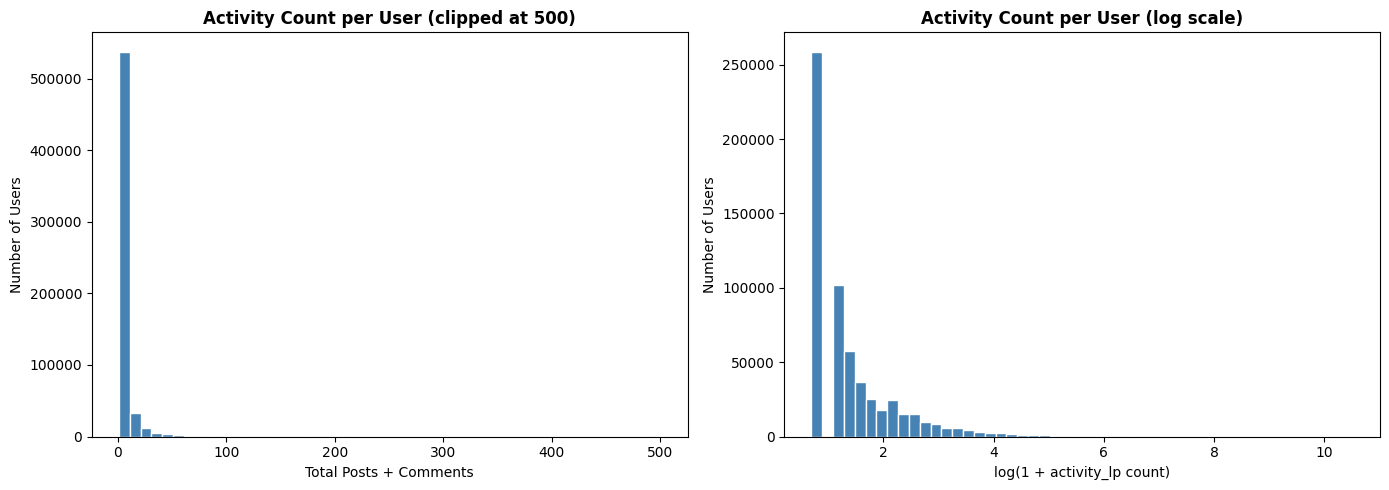

In [150]:
# activity_lp count per user distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_stats_lp['n_activity'].clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Activity Count per User (clipped at 500)', fontweight='bold')
axes[0].set_xlabel('Total Posts + Comments')
axes[0].set_ylabel('Number of Users')

axes[1].hist(np.log1p(user_stats_lp['n_activity']), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Activity Count per User (log scale)', fontweight='bold')
axes[1].set_xlabel('log(1 + activity_lp count)')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

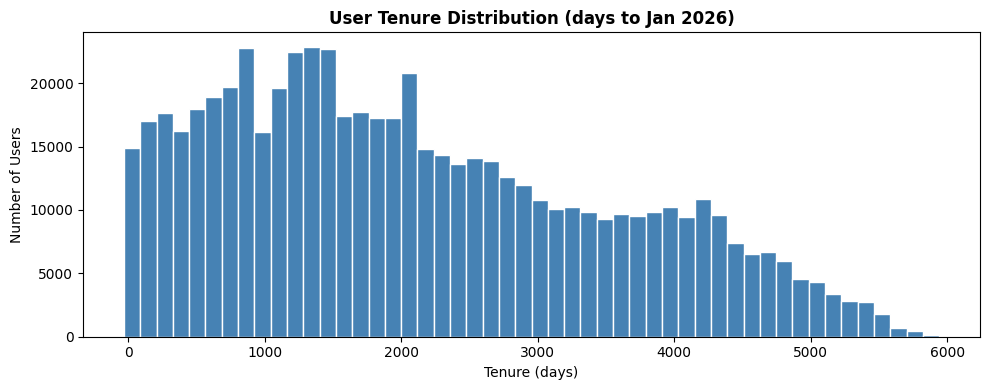

In [151]:
# user tenure distribution
user_stats_lp['tenure_days'] = (OBS_END - user_stats_lp['first_post']).dt.days

plt.figure(figsize=(10, 4))
plt.hist(user_stats_lp['tenure_days'], bins=50, color='steelblue', edgecolor='white')
plt.title('User Tenure Distribution (days to Jan 2026)', fontweight='bold')
plt.xlabel('Tenure (days)')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

In [152]:
# summary stats
user_stats_lp[['n_activity', 'tenure_days']].describe().round(1)

,n_activity,tenure_days
count,601498.0,601498.0
mean,7.5,2117.6
std,102.2,1405.6
min,1.0,-30.0
25%,1.0,971.0
50%,2.0,1877.0
75%,4.0,3141.0
max,37056.0,5942.0


**Note:** The minimum tenure value is -30 days, meaning that a small number of users have their first recorded activity up to 30 days after the observation cutoff of January 1, 2026. This is a data collection artifact: the Arctic Shift archive includes some posts and comments from January 2026 that were captured beyond the cutoff date. In Part 6, these users produce a negative T value and are automatically removed by the `bgnbd[bgnbd['T'] > 0]` filter, so they have no effect on BG/NBD modeling.

**Explanation:**

- **The activity distribution** is strongly right-skewed. The median user has only 2 total posts or comments, while the mean is 7.5. A small number of highly active users pull the mean upward considerably, with the most active user contributing 37,056 interactions. This pattern is typical of online communities, where a minority of users account for the majority of content.

- **User tenure** also varies widely. The median tenure is about 1,877 days (roughly 5 years) and the mean is 2,118 days, indicating that r/learnprogramming has accumulated both long-term participants and a large base of occasional visitors over its history.

### Part-4: Community Activity

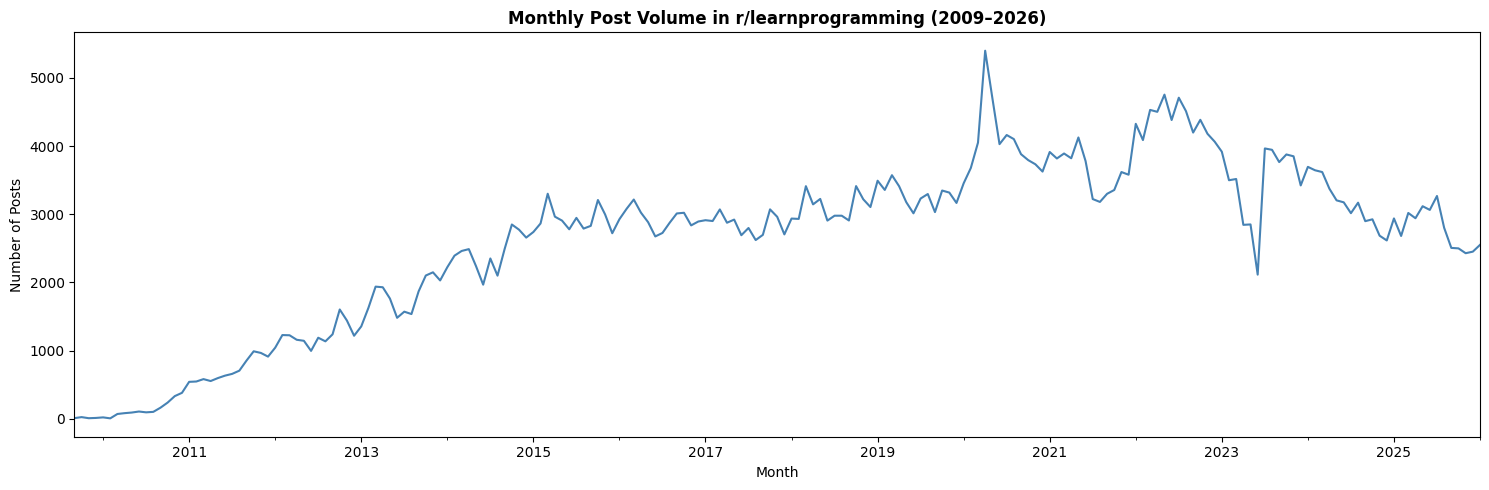

In [153]:
# monthly post volume over time
monthly_posts = posts_lp.groupby(posts_lp['created_utc'].dt.to_period('M')).size()

plt.figure(figsize=(15, 5))
monthly_posts.plot(color='steelblue', lw=1.5)
plt.title('Monthly Post Volume in r/learnprogramming (2009–2026)', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()

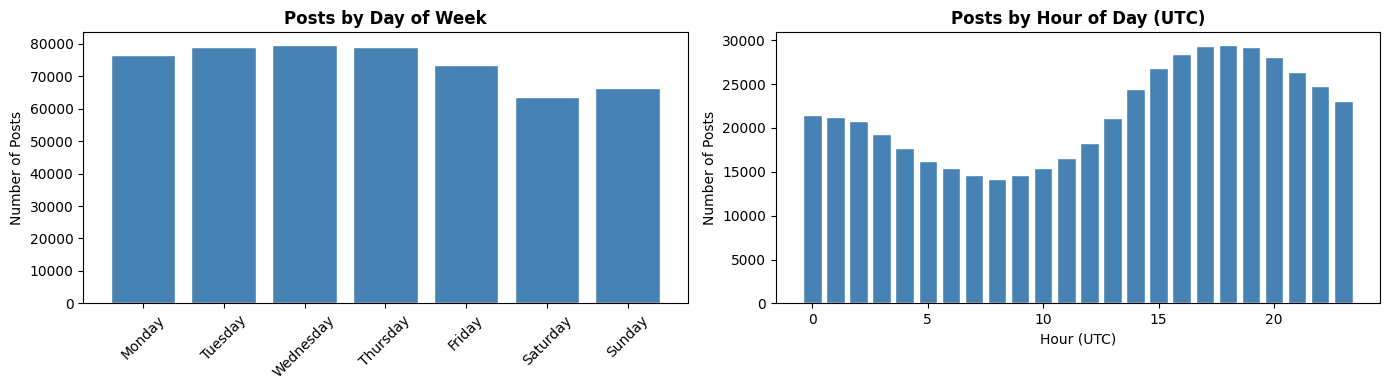

In [154]:
# post volume by day of week and hour of day
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily  = posts_lp['created_utc'].dt.day_name().value_counts().reindex(day_order)
hourly = posts_lp['created_utc'].dt.hour.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(daily.index, daily.values, color='steelblue', edgecolor='white')
axes[0].set_title('Posts by Day of Week', fontweight='bold')
axes[0].set_ylabel('Number of Posts')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
axes[1].set_title('Posts by Hour of Day (UTC)', fontweight='bold')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Number of Posts')

plt.tight_layout()
plt.show()

**Explanation:**

- **The monthly post volume chart** shows that r/learnprogramming experienced sustained growth from its founding in 2009, with activity expanding substantially through the 2010s and reaching consistently high levels in recent years. 
- **The day-of-week bar chart** shows that weekday posting is more common than weekend posting, which is consistent with the community's focus on learning and skill development tied to school and work schedules. 
- **The hourly bar chart** (UTC) reveals that activity is concentrated during certain daytime hours, reflecting the geographic distribution of the active user base.

### Part-5: Content Overview

In [155]:
# text posts vs link posts
has_selftext = posts_lp['selftext'].notna() & (posts_lp['selftext'].str.strip() != '')
print(f'text posts: {has_selftext.sum():,}  ({has_selftext.mean()*100:.1f}%)')
print(f'link posts: {(~has_selftext).sum():,}  ({(~has_selftext).mean()*100:.1f}%)')

text posts: 462,330  (89.4%)
link posts: 54,749  (10.6%)


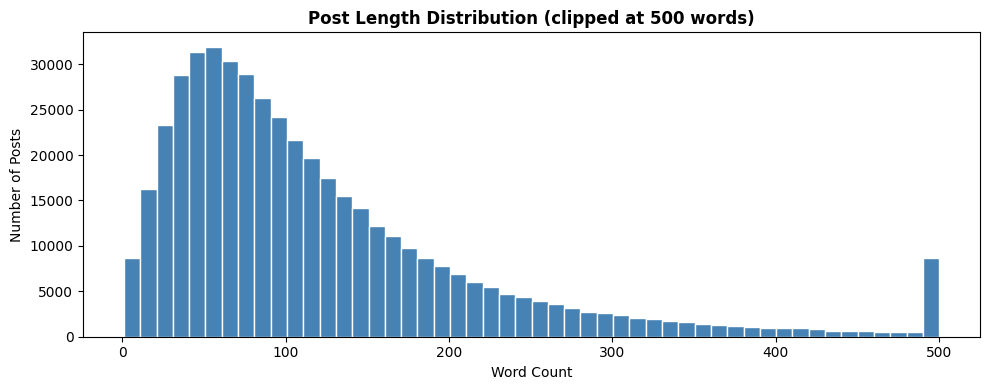

median: 93 words  |  mean: 127 words


In [156]:
# selftext length distribution (text posts only)
text_posts = posts_lp[has_selftext].copy()
text_posts['selftext_words'] = text_posts['selftext'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
plt.hist(text_posts['selftext_words'].clip(upper=500), bins=50, color='steelblue', edgecolor='white')
plt.title('Post Length Distribution (clipped at 500 words)', fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()

print(f'median: {text_posts["selftext_words"].median():.0f} words  |  mean: {text_posts["selftext_words"].mean():.0f} words')

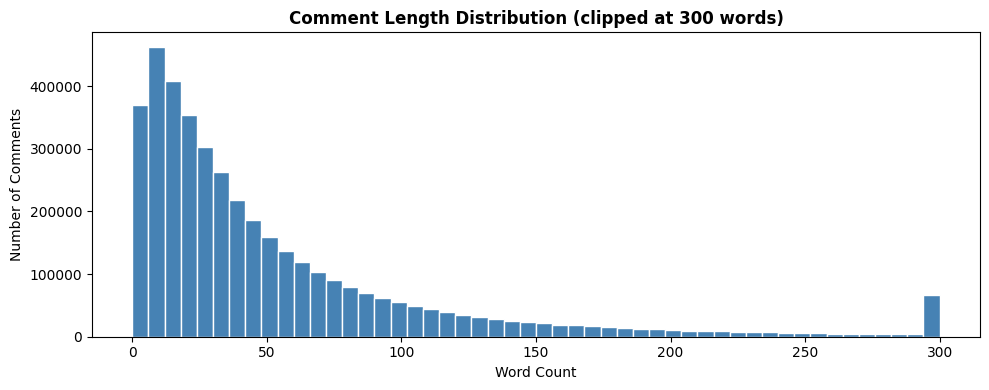

median: 32 words  |  mean: 55 words


In [157]:
# comment body length distribution
valid_comments = comments_lp[comments_lp['body'].notna()].copy()
valid_comments['body_words'] = valid_comments['body'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
plt.hist(valid_comments['body_words'].clip(upper=300), bins=50, color='steelblue', edgecolor='white')
plt.title('Comment Length Distribution (clipped at 300 words)', fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.show()

print(f'median: {valid_comments["body_words"].median():.0f} words  |  mean: {valid_comments["body_words"].mean():.0f} words')

**Note:** The spike at 500 words in the post length histogram and at 300 words in the comment length histogram is not a data anomaly. It is caused by the `.clip(upper=500)` and `.clip(upper=300)` operations: all posts with more than 500 words are mapped to exactly 500, and all comments with more than 300 words are mapped to exactly 300. This causes all records beyond the threshold to stack up at the boundary value, creating an artificially tall bar. The underlying data is normal.

**Explanation:**

The majority of posts in r/learnprogramming are text posts (89.4%), with only 10.6% being link posts. This indicates that users primarily come to the community to ask questions and share written content rather than to link external resources, which is expected for a learning-oriented subreddit.

Among text posts, the median length is 93 words and the mean is 127 words, suggesting that most users write moderately detailed posts when seeking help. Comments are shorter on average, with a median of 32 words and a mean of 55 words. Both distributions are right-skewed, with a small number of posts and comments considerably longer than the typical entry.

### Part-6: BG/NBD Inputs

In [158]:
# compute BG/NBD inputs per qualifying user
bgnbd_lp = user_stats_lp.copy()
bgnbd_lp['T']         = (OBS_END - bgnbd_lp['first_post']).dt.days / 7
bgnbd_lp['recency']   = (bgnbd_lp['last_post'] - bgnbd_lp['first_post']).dt.days / 7
bgnbd_lp['frequency'] = bgnbd_lp['n_activity'] - 1

bgnbd_lp = bgnbd_lp[bgnbd_lp['T'] > 0].reset_index(drop=True)
print(f'users for BG/NBD modeling: {len(bgnbd_lp):,}')
bgnbd_lp[['frequency', 'recency', 'T']].head()

users for BG/NBD modeling: 597,686


,frequency,recency,T
0,6,419.857143,421.857143
1,0,0.000000,342.142857
2,1,0.285714,50.857143
3,0,0.000000,289.571429
4,0,0.000000,250.000000


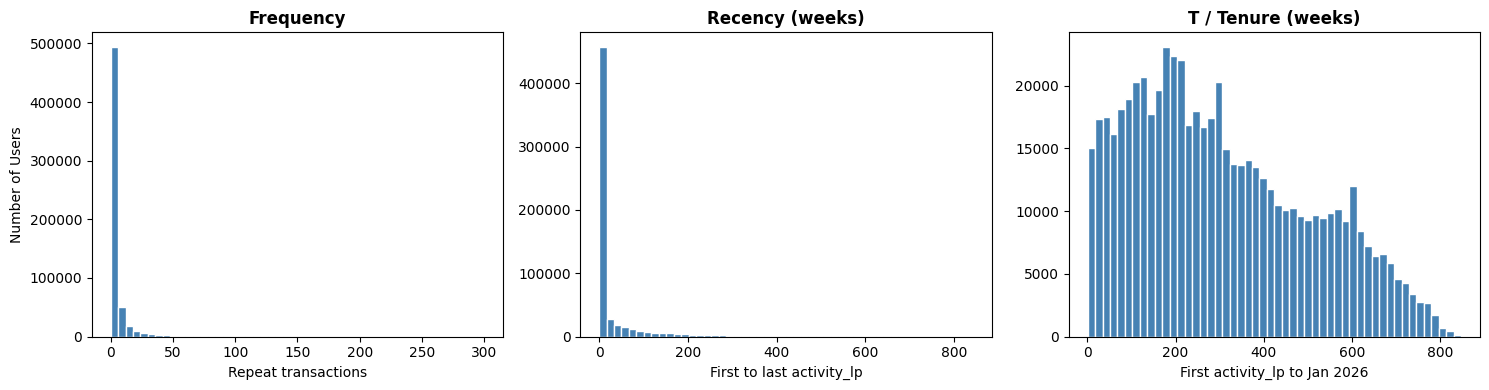

In [159]:
# frequency, recency, T distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(bgnbd_lp['frequency'].clip(upper=300), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Frequency', fontweight='bold')
axes[0].set_xlabel('Repeat transactions')
axes[0].set_ylabel('Number of Users')

axes[1].hist(bgnbd_lp['recency'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Recency (weeks)', fontweight='bold')
axes[1].set_xlabel('First to last activity_lp')

axes[2].hist(bgnbd_lp['T'], bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('T / Tenure (weeks)', fontweight='bold')
axes[2].set_xlabel('First activity_lp to Jan 2026')

plt.tight_layout()
plt.show()

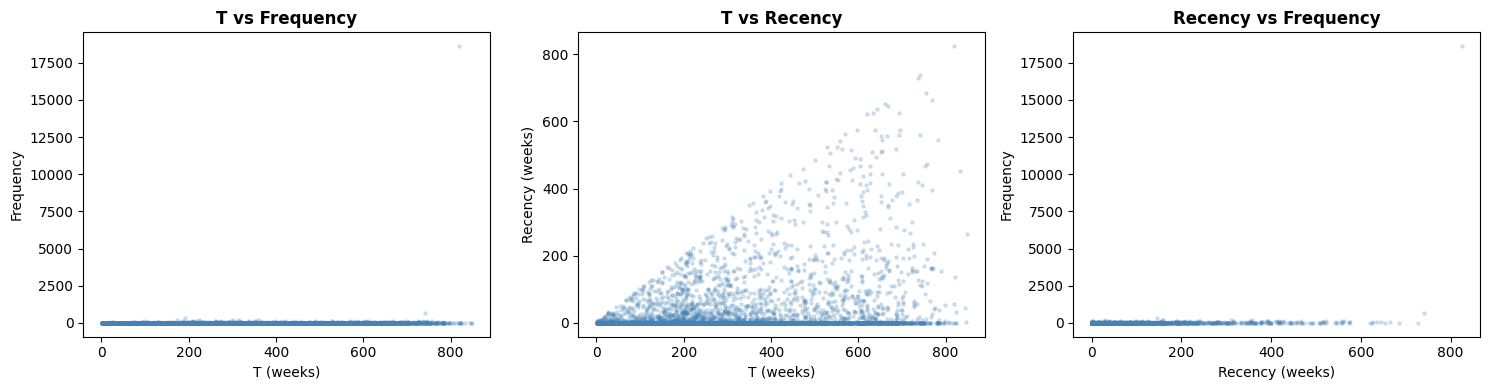

In [160]:
# pairwise scatter plots (sample 5000 users for readability)
sample = bgnbd_lp.sample(min(5000, len(bgnbd_lp)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(sample['T'], sample['frequency'], alpha=0.2, s=5, color='steelblue')
axes[0].set_xlabel('T (weeks)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('T vs Frequency', fontweight='bold')

axes[1].scatter(sample['T'], sample['recency'], alpha=0.2, s=5, color='steelblue')
axes[1].set_xlabel('T (weeks)')
axes[1].set_ylabel('Recency (weeks)')
axes[1].set_title('T vs Recency', fontweight='bold')

axes[2].scatter(sample['recency'], sample['frequency'], alpha=0.2, s=5, color='steelblue')
axes[2].set_xlabel('Recency (weeks)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Recency vs Frequency', fontweight='bold')

plt.tight_layout()
plt.show()

In [161]:
# summary stats
bgnbd_lp[['frequency', 'recency', 'T']].describe().round(2)

,frequency,recency,T
count,597686.00,597686.00,597686.00
mean,6.57,30.74,304.45
std,102.55,81.47,199.95
min,0.00,0.00,0.14
25%,0.00,0.00,141.29
50%,1.00,0.00,270.00
75%,3.00,12.57,450.43
max,37055.00,842.57,848.86


**Explanation:**

The three BG/NBD input variables are all strongly right-skewed, which is consistent with what the model expects.

- **Frequency** (number of repeat transactions after the first): the median is 1 and the mean is 6.57, indicating that most users have very few return visits. A small number of highly active users extend the tail up to a maximum of 37,055.

- **Recency** (weeks from first to last activity): the median recency is 0 weeks, meaning that more than half of users made their first and last activity within the same week (or appeared only once). The mean recency is 30.74 weeks, driven upward by the subset of users who returned over a longer period.

- **T** (weeks from first activity to the observation end date of January 2026): the median T is 270 weeks (about 5.2 years) and the mean is 304 weeks. This indicates that a large share of the user base joined the subreddit several years before the observation cutoff.

The scatter plots confirm that recency is always less than or equal to T for every user, which is a required constraint for the BG/NBD model. The T vs. Frequency plot shows that long tenure does not necessarily translate into high frequency, further supporting the view that most users remain low-engagement contributors regardless of how long they have been registered.

### Part-7: Network Preview

In [162]:
# build reply edges from parent_id
# 't1_' prefix means reply to a comment; strip prefix to get parent comment's base id
comment_author_lp = comments_lp.set_index('id')['author'].to_dict()

replies_lp = comments_lp[comments_lp['parent_id'].str.startswith('t1_', na=False)].copy()
replies_lp['parent_comment_id'] = replies_lp['parent_id'].str[3:]
replies_lp['parent_author']     = replies_lp['parent_comment_id'].map(comment_author_lp)

edges_lp = replies_lp[['author', 'parent_author']].dropna()
edges_lp = edges_lp[edges_lp['author'] != edges_lp['parent_author']]

print(f'total reply edges:             {len(edges_lp):,}')
print(f'unique users in reply network: {pd.concat([edges_lp["author"], edges_lp["parent_author"]]).nunique():,}')

total reply edges:             1,998,645
unique users in reply network: 369,537


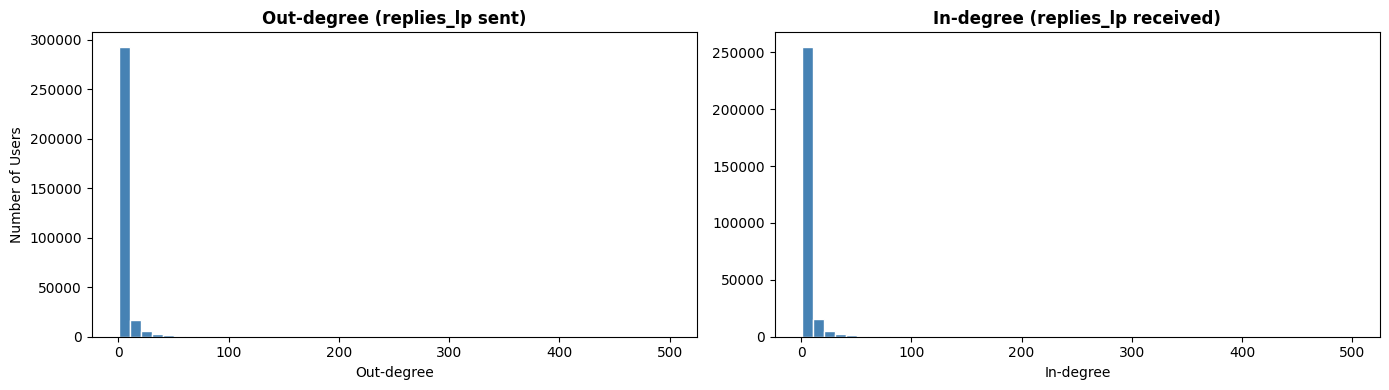

In [163]:
# in-degree and out-degree distributions
out_deg_lp = edges_lp['author'].value_counts()
in_deg_lp  = edges_lp['parent_author'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(out_deg_lp.clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Out-degree (replies_lp sent)', fontweight='bold')
axes[0].set_xlabel('Out-degree')
axes[0].set_ylabel('Number of Users')

axes[1].hist(in_deg_lp.clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('In-degree (replies_lp received)', fontweight='bold')
axes[1].set_xlabel('In-degree')

plt.tight_layout()
plt.show()

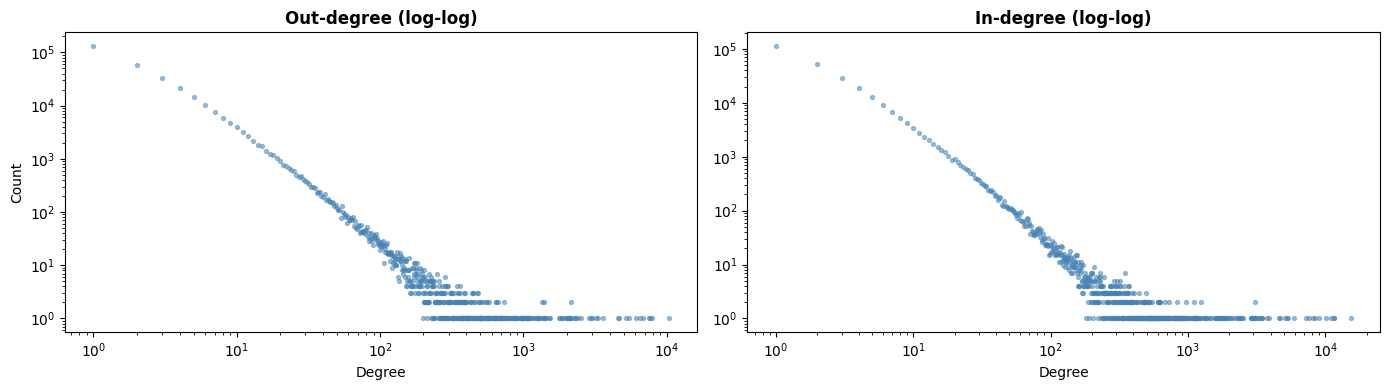

In [164]:
# log-log degree distribution (power-law check)
out_deg_counts = out_deg_lp.value_counts().sort_index()
in_deg_counts  = in_deg_lp.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(out_deg_counts.index, out_deg_counts.values, alpha=0.5, s=8, color='steelblue')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Out-degree (log-log)', fontweight='bold')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')

axes[1].scatter(in_deg_counts.index, in_deg_counts.values, alpha=0.5, s=8, color='steelblue')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('In-degree (log-log)', fontweight='bold')
axes[1].set_xlabel('Degree')

plt.tight_layout()
plt.show()

In [165]:
# basic network stats
all_users = pd.concat([edges_lp['author'], edges_lp['parent_author']])
print(f'nodes:             {all_users.nunique():,}')
print(f'edges:             {len(edges_lp):,}')
print(f'avg out-degree:    {out_deg_lp.mean():.2f}')
print(f'median out-degree: {out_deg_lp.median():.0f}')
print(f'max out-degree:    {out_deg_lp.max():,}')

nodes:             369,537
edges:             1,998,645
avg out-degree:    6.17
median out-degree: 2
max out-degree:    10,276


**Explanation:**

- **The reply network** contains 1,998,645 directed edges connecting 369,537 unique users. Each edge represents one user directly replying to another user's comment. Out of 601,498 qualifying users, about 61.4% appear in the reply network, meaning a substantial portion of users only posted top-level content without engaging in direct reply exchanges.

- **The out-degree distribution**(replies sent) and **in-degree distribution** (replies received) are both heavily right-skewed. The average out-degree is 6.17, but the median is only 2, indicating that most users sent very few replies while a small number of users sent a disproportionately large share. The most active replier sent 10,276 replies.

- **The log-log degree distribution plots** show an approximately linear trend for both in-degree and out-degree, which is consistent with a power-law distribution. This is a common structural property of social networks and suggests that the r/learnprogramming reply network has a small number of highly connected "hubs" alongside a large majority of users with minimal connectivity.

#### Part-7: Network Preview 2.0

r/learnprogramming — 312,413 / 573,196 users in network (54.5%)
  Mean out-degree    : 4.73
  Mean in-degree     : 4.55
  Mean k-core        : 3.41
  Mean clustering    : 0.0699
  Mean community size: 60822.3


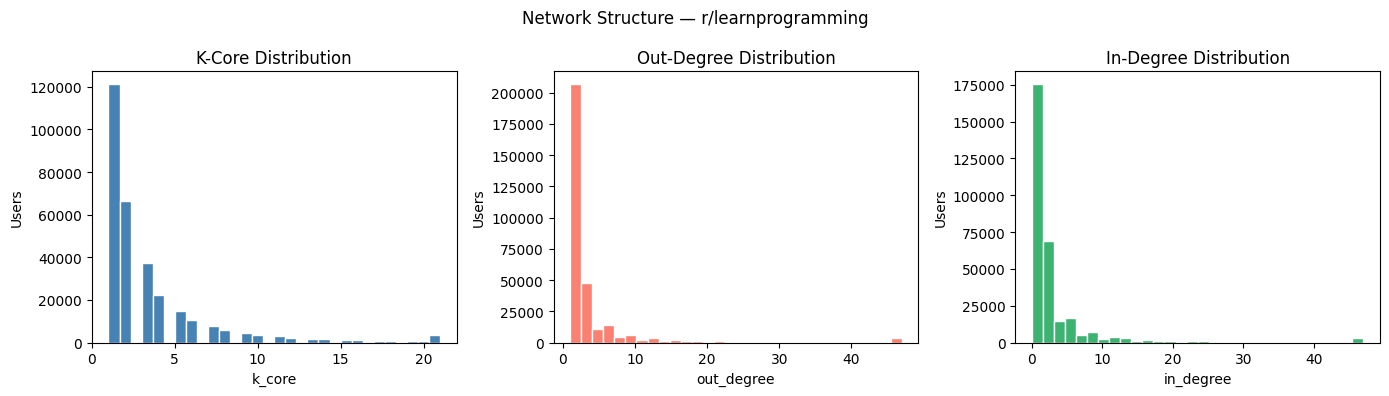

In [ ]:
# Network structure — r/learnprogramming
import pandas as pd, numpy as np, matplotlib.pyplot as plt

feat   = pd.read_parquet('../data/processed_data/features_net_lp.parquet')
in_net = feat[feat['out_degree'] > 0]
pct    = len(in_net) / len(feat) * 100

print(f'r/learnprogramming — {len(in_net):,} / {len(feat):,} users in network ({pct:.1f}%)')
print(f'  Mean out-degree    : {in_net["out_degree"].mean():.2f}')
print(f'  Mean in-degree     : {in_net["in_degree"].mean():.2f}')
print(f'  Mean k-core        : {in_net["k_core"].mean():.2f}')
print(f'  Mean clustering    : {in_net["clustering_coef"].mean():.4f}')
print(f'  Mean community size: {in_net["community_size"].mean():.1f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Network Structure — r/learnprogramming', fontsize=12)

for ax, (col, title, color) in zip(axes, [
    ('k_core',     'K-Core Distribution',    'steelblue'),
    ('out_degree', 'Out-Degree Distribution', 'salmon'),
    ('in_degree',  'In-Degree Distribution',  'mediumseagreen'),
]):
    vals = in_net[col].clip(upper=in_net[col].quantile(0.99))
    ax.hist(vals, bins=30, color=color, edgecolor='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Users')
    ax.set_title(title)

plt.tight_layout()
plt.show()


## Subreddit-2: loseit

### Part-1: Data Overview

In [166]:
DATA_DIR = '/Users/yangshuting/Desktop/UChicago/courses/spring_2026/MACS_30200_Research_Design/final_proposal/data/raw_data/loseit/'
POSTS_PATH    = DATA_DIR + 'r_loseit_posts.jsonl'
COMMENTS_PATH = DATA_DIR + 'r_loseit_comments.jsonl'
OBS_END = pd.Timestamp('2026-01-01', tz='UTC')

In [167]:
# load posts - keep only needed columns
POSTS_COLS = ['author', 'created_utc', 'id', 'title', 'selftext', 'score', 'num_comments']

posts = []
with open(POSTS_PATH) as f:
    for line in f:
        d = json.loads(line)
        posts.append({k: d.get(k) for k in POSTS_COLS})

posts_loseit = pd.DataFrame(posts)
n_posts_raw = len(posts_loseit)
posts_loseit.shape

(704054, 7)

In [168]:
# load comments - keep only needed columns
COMMENTS_COLS = ['author', 'created_utc', 'id', 'body', 'score', 'parent_id', 'link_id']

comments = []
with open(COMMENTS_PATH) as f:
    for line in f:
        d = json.loads(line)
        comments.append({k: d.get(k) for k in COMMENTS_COLS})

comments_loseit = pd.DataFrame(comments)
n_comments_raw = len(comments_loseit)
comments_loseit.shape

(8594416, 7)

In [169]:
# get an overview of posts
posts_loseit.head()

,author,created_utc,id,title,selftext,score,num_comments
0,[deleted],1280433732,cv7o0,What is your goal?,[deleted],21,52
1,[deleted],1280463859,cvcnm,What are your personal tips and tricks?,[deleted],5,8
2,mindspread,1280492593,cvgl4,Why it's really important to look up nutrition...,,9,1
3,Beatle_Matt,1280497298,cvhel,Low carb or calorie counting...or both?,"Between April of '09, and April of '10 I lost ...",8,11
4,[deleted],1280498789,cvhol,"I lost 20 pounds on the ""Quit eating so much!""...","Seriously, I did lose 20 lbs over the course o...",10,14


In [170]:
# get an overview of comments
comments_loseit.head()

,author,created_utc,id,body,score,parent_id,link_id
0,BigRedDSP,1280434228,c0vifu6,I'm 6'2'' and currently 227. I was somewhere ...,6,t3_cv7o0,t3_cv7o0
1,mindspread,1280434736,c0vigwj,"good first post!.\n\nI am a 34 year old, 5'10""...",12,t3_cv7o0,t3_cv7o0
2,urrkuz,1280434940,c0vihbe,"I'm a 22 year old female, I am 5'5"" and curren...",11,t3_cv7o0,t3_cv7o0
3,theclapp,1280436753,c0vikqu,41 / m / 6 ft. Started @ 226 in late Feb 2010...,6,t3_cv7o0,t3_cv7o0
4,Caldosa,1280437746,c0vimi7,"First of all, congrats on the incredible progr...",5,t1_c0vigwj,t3_cv7o0


In [171]:
# check data types
posts_loseit.dtypes

author          object
created_utc      int64
id              object
title           object
selftext        object
score            int64
num_comments     int64
dtype: object

### Part-2: Data Cleaning

#### 2.1 Remove missing values

In [172]:
# check missing values
null_posts    = posts_loseit.isnull().sum()
null_comments = comments_loseit.isnull().sum()
print('=== Posts ===')
print(null_posts)
print('\n=== Comments ===')
print(null_comments)

=== Posts ===
author          0
created_utc     0
id              0
title           0
selftext        0
score           0
num_comments    0
dtype: int64

=== Comments ===
author         0
created_utc    0
id             0
body           0
score          0
parent_id      0
link_id        0
dtype: int64


In [173]:
# drop columns that have at least 30% missing values
posts_loseit.drop(columns=posts_loseit.columns[null_posts > len(posts_loseit) * 0.3], inplace=True)
comments_loseit.drop(columns=comments_loseit.columns[null_comments > len(comments_loseit) * 0.3], inplace=True)

# check remaining columns
print('posts columns:', posts_loseit.columns.tolist())
print('comments columns:', comments_loseit.columns.tolist())

posts columns: ['author', 'created_utc', 'id', 'title', 'selftext', 'score', 'num_comments']
comments columns: ['author', 'created_utc', 'id', 'body', 'score', 'parent_id', 'link_id']


The same result is observed as in Subreddit-1: all selected columns have zero missing values. The core Reddit fields I loaded are always present in the source data, so no imputation or column removal is needed.

#### 2.2 Remove duplicates

In [174]:
# check duplicate content: same user posting identical text
# posts: same author + same title; comments: same author + same body
dup_posts    = posts_loseit.duplicated(subset=['author', 'title'], keep=False).sum()
dup_comments = comments_loseit.duplicated(subset=['author', 'body'], keep=False).sum()

print(f'duplicate posts (same author + title):   {dup_posts:,}')
print(f'duplicate comments (same author + body): {dup_comments:,}')

duplicate posts (same author + title):   45,324
duplicate comments (same author + body): 703,946


In [175]:
# drop duplicates, keep first occurrence
posts_loseit    = posts_loseit.drop_duplicates(subset=['author', 'title'], keep='first').reset_index(drop=True)
comments_loseit = comments_loseit.drop_duplicates(subset=['author', 'body'],  keep='first').reset_index(drop=True)

n_posts_after_dedup    = len(posts_loseit)
n_comments_after_dedup = len(comments_loseit)
print(f'posts after dedup:    {n_posts_after_dedup:,}')
print(f'comments after dedup: {n_comments_after_dedup:,}')

posts after dedup:    672,369
comments after dedup: 7,922,030


#### 2.3 Remove user-deleted accounts

In [176]:
# check [deleted] author proportion
print('=== Posts ===')
print(f'total: {len(posts_loseit):,}')
print(f'[deleted]: {(posts_loseit["author"] == "[deleted]").sum():,}  ({(posts_loseit["author"] == "[deleted]").mean()*100:.1f}%)')
print(f'[removed]: {(posts_loseit["author"] == "[removed]").sum():,}')

print('\n=== Comments ===')
print(f'total: {len(comments_loseit):,}')
print(f'[deleted]: {(comments_loseit["author"] == "[deleted]").sum():,}  ({(comments_loseit["author"] == "[deleted]").mean()*100:.1f}%)')
print(f'[removed]: {(comments_loseit["author"] == "[removed]").sum():,}')

=== Posts ===
total: 672,369
[deleted]: 138,200  (20.6%)
[removed]: 0

=== Comments ===
total: 7,922,030
[deleted]: 185,558  (2.3%)
[removed]: 0


In [177]:
# remove user-deleted accounts
posts_loseit    = posts_loseit[~posts_loseit['author'].isin(['[deleted]', '[removed]'])].reset_index(drop=True)
comments_loseit = comments_loseit[~comments_loseit['author'].isin(['[deleted]', '[removed]'])].reset_index(drop=True)

n_posts_after_deleted    = len(posts_loseit)
n_comments_after_deleted = len(comments_loseit)
print(f'posts after filtering:    {n_posts_after_deleted:,}')
print(f'comments after filtering: {n_comments_after_deleted:,}')

posts after filtering:    534,169
comments after filtering: 7,736,472


`[removed]` does not appear in the `author` column, consistent with the pattern in Subreddit-1. Moderator removals affect only the content fields (`selftext`/`body`), not the `author` field. Refer to the explanation in Subreddit-1's 2.3 for details.

#### 2.4 Remove mod-deleted post and comment content

In [178]:
# check [deleted] / [removed] text in content fields
print(f'posts with [deleted] selftext:  {(posts_loseit["selftext"] == "[deleted]").sum():,}')
print(f'posts with [removed] selftext:  {(posts_loseit["selftext"] == "[removed]").sum():,}')
print(f'comments with [deleted] body:   {(comments_loseit["body"] == "[deleted]").sum():,}')
print(f'comments with [removed] body:   {(comments_loseit["body"] == "[removed]").sum():,}')

posts with [deleted] selftext:  5
posts with [removed] selftext:  125,890
comments with [deleted] body:   18
comments with [removed] body:   3


In [179]:
# replace [deleted] / [removed] text with NaN
posts_loseit['selftext'] = posts_loseit['selftext'].replace(['[deleted]', '[removed]'], None)
comments_loseit['body']  = comments_loseit['body'].replace(['[deleted]', '[removed]'], None)

# re-check missing after replacing
print(f'selftext missing after cleaning: {posts_loseit["selftext"].isnull().sum():,}')
print(f'body missing after cleaning:     {comments_loseit["body"].isnull().sum():,}')

selftext missing after cleaning: 125,895
body missing after cleaning:     21


#### 2.5 Remove bots

In [180]:
# check top 30 most active commenters to identify bots
top_commenters = comments_loseit['author'].value_counts().head(30)
top_commenters

author
funchords              59631
Jynxers                24463
cenosillicaphobiac     21822
ificandoit             14782
mionni                 14424
Mountainlioness404d    14109
SmilingJaguar          12851
SDJellyBean            11271
AutoModerator          10476
ana30671                8705
anbeav                  8316
malica77                8302
Jolan                   7672
cmxguru                 7666
Strategic_Sage          7518
Infamous-Pilot5932      7361
denovosibi              7174
asawmark                6970
HermionesBook           6954
Mastgoboom              6949
nofollowthrough         6583
visilliis               6537
BugZwugZ                6457
bertzie                 6277
ThatCanadianGuy88       6078
Southern_Print_3966     5806
Jillatha                5662
walkSMASHwalk           5633
EllaCOfficial           5425
Rewind2013              5095
Name: count, dtype: int64

In [181]:
# define known bots and remove them
BOTS = [
    'AutoModerator', 'BotDefense', 'RepostSleuthBot', 'snapshillbot',
    'WikiTextBot', 'LinkifyBot', 'TweetPoster', 'imgurtranscriber',
    'MAGIC_EYE_BOT', 'RemindMeBot', 'haikusbot', 'converter-bot'
]

posts_loseit    = posts_loseit[~posts_loseit['author'].isin(BOTS)].reset_index(drop=True)
comments_loseit = comments_loseit[~comments_loseit['author'].isin(BOTS)].reset_index(drop=True)

n_posts_after_bots    = len(posts_loseit)
n_comments_after_bots = len(comments_loseit)
print(f'posts after bot removal:    {n_posts_after_bots:,}')
print(f'comments after bot removal: {n_comments_after_bots:,}')

posts after bot removal:    521,920
comments after bot removal: 7,725,732


#### 2.6 User activity records and low-activity filtering

In [182]:
# convert timestamps
posts_loseit['created_utc']    = pd.to_datetime(posts_loseit['created_utc'], unit='s', utc=True)
comments_loseit['created_utc'] = pd.to_datetime(comments_loseit['created_utc'], unit='s', utc=True)

In [183]:
# each post/comment = one transaction (following BG/NBD convention)
activity_loseit = pd.concat([
    posts_loseit[['author', 'created_utc']],
    comments_loseit[['author', 'created_utc']]
], ignore_index=True).sort_values('created_utc').reset_index(drop=True)

print(f'total activity_loseit records: {len(activity_loseit):,}')

total activity_loseit records: 8,247,652


In [184]:
# compute per-user activity_loseit stats
user_stats_loseit = activity_loseit.groupby('author').agg(
    n_activity = ('created_utc', 'count'),
    first_post = ('created_utc', 'min'),
    last_post  = ('created_utc', 'max')
).reset_index()

print(f'total unique users: {len(user_stats_loseit):,}')
user_stats_loseit.head()

total unique users: 792,129


,author,n_activity,first_post,last_post
0,--------____-------,1,2021-10-26 03:45:06+00:00,2021-10-26 03:45:06+00:00
1,------________,14,2016-11-16 04:35:09+00:00,2017-11-08 18:31:13+00:00
2,-----0-----,1,2023-07-27 14:17:38+00:00,2023-07-27 14:17:38+00:00
3,-----Andrew-----,1,2017-08-13 04:22:16+00:00,2017-08-13 04:22:16+00:00
4,-----Ash-----,1,2019-02-16 14:03:13+00:00,2019-02-16 14:03:13+00:00


In [185]:
# compute the bottom 5% activity_loseit threshold (calculated per subreddit)
threshold = int(user_stats_loseit['n_activity'].quantile(0.05))
print(f'bottom 5% threshold: {threshold} activities')
print(f'users before filter: {len(user_stats_loseit):,}')

bottom 5% threshold: 1 activities
users before filter: 792,129


In [186]:
# drop users below the threshold
user_stats_loseit = user_stats_loseit[user_stats_loseit['n_activity'] >= threshold].reset_index(drop=True)
qualifying_users_loseit = set(user_stats_loseit['author'])

# filter activity_loseit, posts_loseit, comments_loseit to qualifying users only
activity_loseit    = activity_loseit[activity_loseit['author'].isin(qualifying_users_loseit)].reset_index(drop=True)
posts_loseit    = posts_loseit[posts_loseit['author'].isin(qualifying_users_loseit)].reset_index(drop=True)
comments_loseit = comments_loseit[comments_loseit['author'].isin(qualifying_users_loseit)].reset_index(drop=True)

print(f'qualifying users:   {len(user_stats_loseit):,}')
print(f'posts (final):      {len(posts_loseit):,}')
print(f'comments (final):   {len(comments_loseit):,}')

qualifying users:   792,129
posts (final):      521,920
comments (final):   7,725,732


#### 2.7 Cleaned data overview

In [187]:
# cleaning steps summary
summary = pd.DataFrame({
    'Step': [
        'Raw posts', 'Raw comments',
        'After removing duplicates (posts)', 'After removing duplicates (comments)',
        'After removing [deleted] authors (posts)', 'After removing [deleted] authors (comments)',
        'After removing bots (posts)', 'After removing bots (comments)',
        'Final posts (qualifying users only)', 'Final comments (qualifying users only)',
        'Qualifying users'
    ],
    'Count': [
        n_posts_raw, n_comments_raw,
        n_posts_after_dedup, n_comments_after_dedup,
        n_posts_after_deleted, n_comments_after_deleted,
        n_posts_after_bots, n_comments_after_bots,
        len(posts_loseit), len(comments_loseit),
        len(user_stats_loseit)
    ]
})
summary

,Step,Count
0,Raw posts,704054
1,Raw comments,8594416
2,After removing duplicates (posts),672369
3,After removing duplicates (comments),7922030
4,After removing [deleted] authors (posts),534169
5,After removing [deleted] authors (comments),7736472
6,After removing bots (posts),521920
7,After removing bots (comments),7725732
8,Final posts (qualifying users only),521920
9,Final comments (qualifying users only),7725732


In [188]:
# final cleaned data summary
print('=== Final Cleaned Data ===')
print(f'posts_loseit:    {len(posts_loseit):,} rows  -- cleaned posts with full text and metadata (qualifying users only)')
print(f'comments_loseit: {len(comments_loseit):,} rows  -- cleaned comments with full text and metadata (qualifying users only)')
print(f'user_stats_loseit:  {len(user_stats_loseit):,} rows  -- per-user activity_loseit stats (n_activity, first_post, last_post)')
print()
print('posts_loseit and comments_loseit are the main data sources for NLP features and network construction.')
print('user_stats_loseit is used to compute BG/NBD inputs (frequency, recency, T) per user.')

=== Final Cleaned Data ===
posts_loseit:    521,920 rows  -- cleaned posts with full text and metadata (qualifying users only)
comments_loseit: 7,725,732 rows  -- cleaned comments with full text and metadata (qualifying users only)
user_stats_loseit:  792,129 rows  -- per-user activity_loseit stats (n_activity, first_post, last_post)

posts_loseit and comments_loseit are the main data sources for NLP features and network construction.
user_stats_loseit is used to compute BG/NBD inputs (frequency, recency, T) per user.


In [189]:
# cleaned data overview
print(f'posts_loseit:    {posts_loseit.shape}')
print(f'comments_loseit: {comments_loseit.shape}')
print(f'user_stats_loseit:  {user_stats_loseit.shape}')
print()
display(posts_loseit.head())
display(comments_loseit.head())

posts_loseit:    (521920, 7)
comments_loseit: (7725732, 7)
user_stats_loseit:  (792129, 4)



,author,created_utc,id,title,selftext,score,num_comments
0,mindspread,2010-07-30 12:23:13+00:00,cvgl4,Why it's really important to look up nutrition...,,9,1
1,Beatle_Matt,2010-07-30 13:41:38+00:00,cvhel,Low carb or calorie counting...or both?,"Between April of '09, and April of '10 I lost ...",8,11
2,RossMan,2010-07-30 16:02:43+00:00,cvj75,"Hey Reddit, I've lost 70 pounds and I'm still ...",I don't want to post pictures until I get to m...,9,3
3,mindspread,2010-07-31 00:04:41+00:00,cvoon,This video was extremely helpful to me in unde...,,11,2
4,aeniman,2010-07-31 04:12:00+00:00,cvqk2,How did you overcome the fear of eating TOO mu...,I'm about 2-2.5 weeks into an attempt at losin...,6,5


,author,created_utc,id,body,score,parent_id,link_id
0,BigRedDSP,2010-07-29 20:10:28+00:00,c0vifu6,I'm 6'2'' and currently 227. I was somewhere ...,6,t3_cv7o0,t3_cv7o0
1,mindspread,2010-07-29 20:18:56+00:00,c0vigwj,"good first post!.\n\nI am a 34 year old, 5'10""...",12,t3_cv7o0,t3_cv7o0
2,urrkuz,2010-07-29 20:22:20+00:00,c0vihbe,"I'm a 22 year old female, I am 5'5"" and curren...",11,t3_cv7o0,t3_cv7o0
3,theclapp,2010-07-29 20:52:33+00:00,c0vikqu,41 / m / 6 ft. Started @ 226 in late Feb 2010...,6,t3_cv7o0,t3_cv7o0
4,Caldosa,2010-07-29 21:09:06+00:00,c0vimi7,"First of all, congrats on the incredible progr...",5,t1_c0vigwj,t3_cv7o0


### Part-3: User Activity

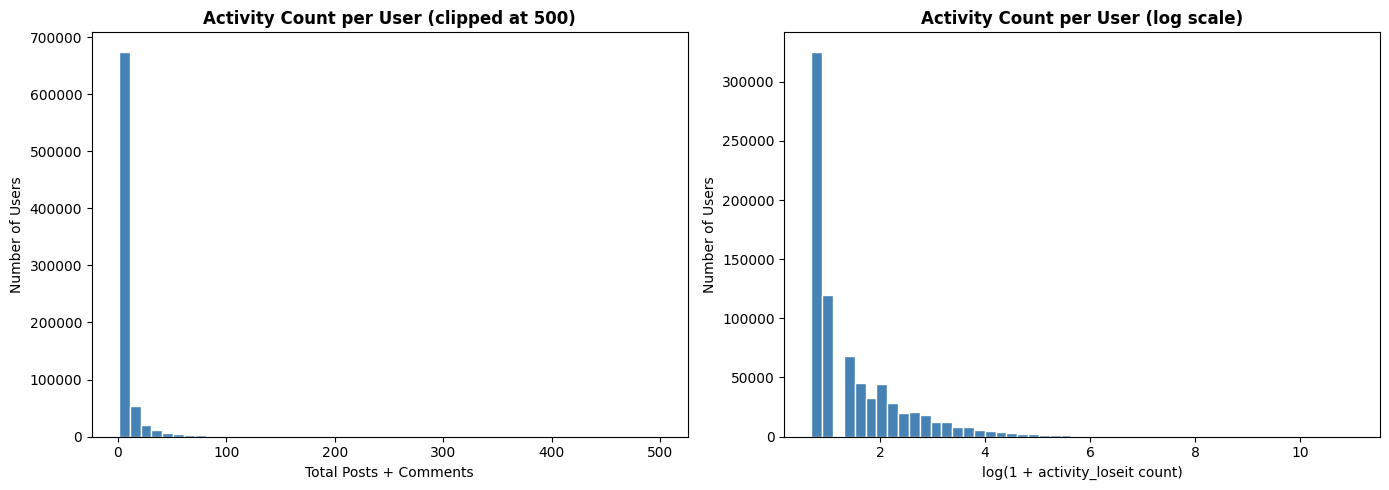

In [190]:
# activity_loseit count per user distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_stats_loseit['n_activity'].clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Activity Count per User (clipped at 500)', fontweight='bold')
axes[0].set_xlabel('Total Posts + Comments')
axes[0].set_ylabel('Number of Users')

axes[1].hist(np.log1p(user_stats_loseit['n_activity']), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Activity Count per User (log scale)', fontweight='bold')
axes[1].set_xlabel('log(1 + activity_loseit count)')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

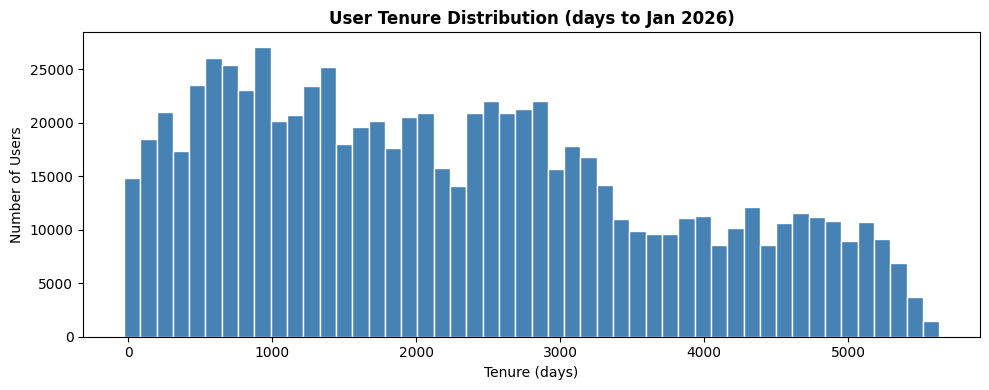

In [191]:
# user tenure distribution
user_stats_loseit['tenure_days'] = (OBS_END - user_stats_loseit['first_post']).dt.days

plt.figure(figsize=(10, 4))
plt.hist(user_stats_loseit['tenure_days'], bins=50, color='steelblue', edgecolor='white')
plt.title('User Tenure Distribution (days to Jan 2026)', fontweight='bold')
plt.xlabel('Tenure (days)')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

In [192]:
# summary stats
user_stats_loseit[['n_activity', 'tenure_days']].describe().round(1)

,n_activity,tenure_days
count,792129.0,792129.0
mean,10.4,2268.3
std,107.7,1476.3
min,1.0,-30.0
25%,1.0,994.0
50%,2.0,2079.0
75%,6.0,3276.0
max,60109.0,5634.0


**Note:** Same as Subreddit-1, the minimum tenure of -30 days is a data collection artifact caused by records from January 2026 falling after the observation cutoff. These users are automatically excluded in Part 6 by the T > 0 filter and do not affect the modeling.

**Explanation:**

- **The activity distribution** is strongly right-skewed. The median user has only 2 total posts or comments, while the mean is 10.4. A small number of highly active users raise the mean considerably, with the most active user contributing 60,109 interactions. This pattern is consistent with what was observed in r/learnprogramming and is typical of large online communities.

- **User tenure** also varies widely. The median tenure is about 2,079 days (roughly 5.7 years) and the mean is 2,268 days, suggesting that r/loseit has accumulated a substantial base of long-term members alongside many occasional visitors.

### Part-4: Community Activity

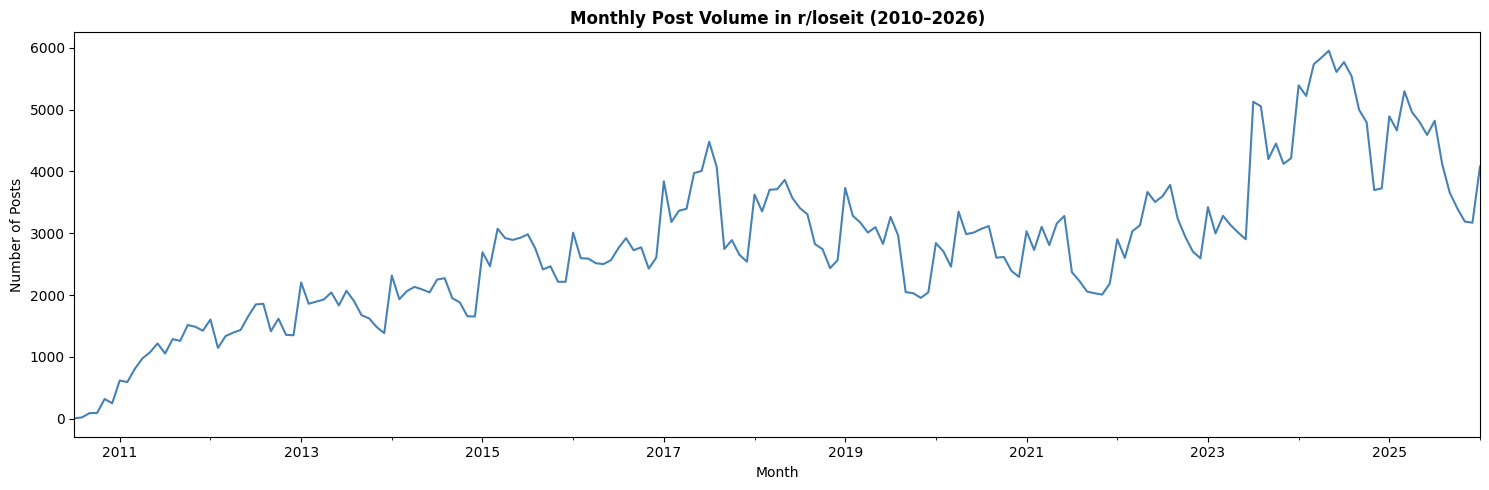

In [193]:
# monthly post volume over time
monthly_posts = posts_loseit.groupby(posts_loseit['created_utc'].dt.to_period('M')).size()

plt.figure(figsize=(15, 5))
monthly_posts.plot(color='steelblue', lw=1.5)
plt.title('Monthly Post Volume in r/loseit (2010–2026)', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()

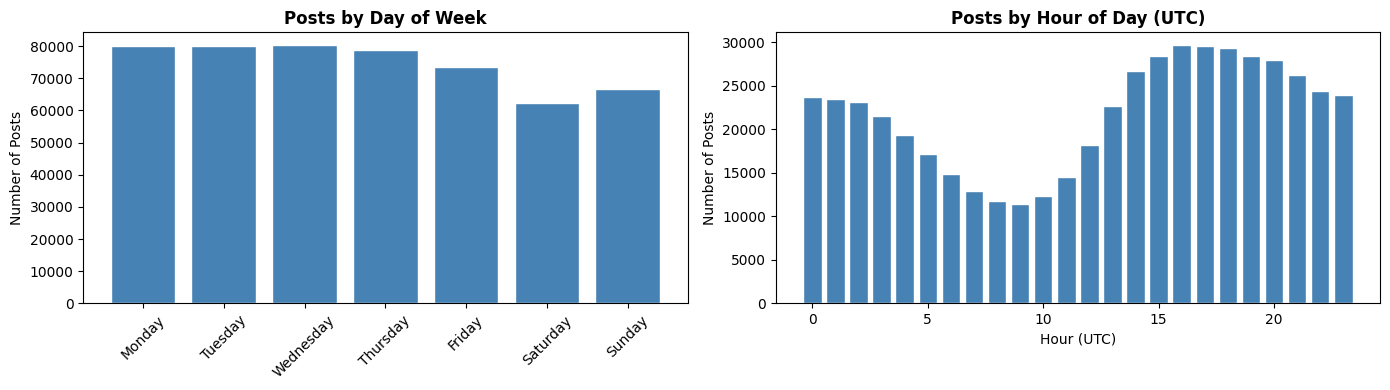

In [194]:
# post volume by day of week and hour of day
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily  = posts_loseit['created_utc'].dt.day_name().value_counts().reindex(day_order)
hourly = posts_loseit['created_utc'].dt.hour.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(daily.index, daily.values, color='steelblue', edgecolor='white')
axes[0].set_title('Posts by Day of Week', fontweight='bold')
axes[0].set_ylabel('Number of Posts')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
axes[1].set_title('Posts by Hour of Day (UTC)', fontweight='bold')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Number of Posts')

plt.tight_layout()
plt.show()

**Explanation:**

- **The monthly post volume chart** shows that r/loseit grew steadily since its founding around 2010, with activity increasing over time and remaining consistently high through early 2026.
- **The day-of-week bar chart** shows some variation across the week, with weekday posting generally more common than weekend posting.
- **The hourly bar chart** (UTC) shows that activity is concentrated during certain daytime hours, reflecting the geographic distribution of the community's active user base.

### Part-5: Content Overview

In [195]:
# text posts vs link posts
has_selftext = posts_loseit['selftext'].notna() & (posts_loseit['selftext'].str.strip() != '')
print(f'text posts: {has_selftext.sum():,}  ({has_selftext.mean()*100:.1f}%)')
print(f'link posts: {(~has_selftext).sum():,}  ({(~has_selftext).mean()*100:.1f}%)')

text posts: 386,913  (74.1%)
link posts: 135,007  (25.9%)


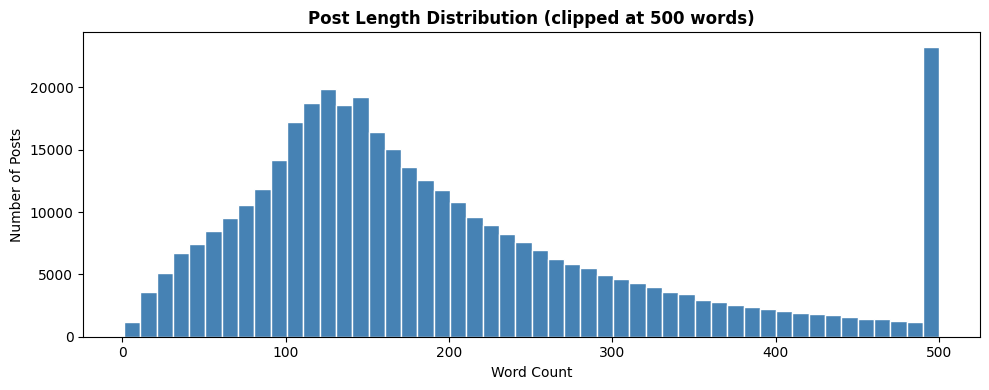

median: 164 words  |  mean: 213 words


In [196]:
# selftext length distribution (text posts only)
text_posts = posts_loseit[has_selftext].copy()
text_posts['selftext_words'] = text_posts['selftext'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
plt.hist(text_posts['selftext_words'].clip(upper=500), bins=50, color='steelblue', edgecolor='white')
plt.title('Post Length Distribution (clipped at 500 words)', fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()

print(f'median: {text_posts["selftext_words"].median():.0f} words  |  mean: {text_posts["selftext_words"].mean():.0f} words')

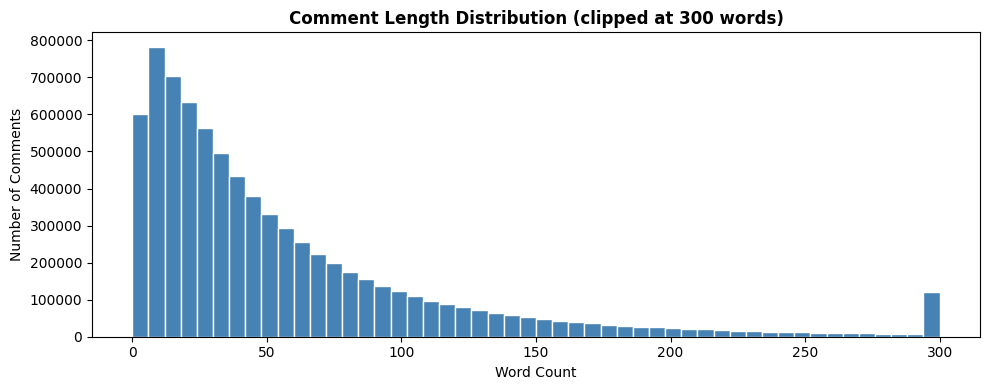

median: 37 words  |  mean: 59 words


In [197]:
# comment body length distribution
valid_comments = comments_loseit[comments_loseit['body'].notna()].copy()
valid_comments['body_words'] = valid_comments['body'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
plt.hist(valid_comments['body_words'].clip(upper=300), bins=50, color='steelblue', edgecolor='white')
plt.title('Comment Length Distribution (clipped at 300 words)', fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.show()

print(f'median: {valid_comments["body_words"].median():.0f} words  |  mean: {valid_comments["body_words"].mean():.0f} words')

**Note:** Same as Subreddit-1, the spikes at 500 words (posts) and 300 words (comments) are a `.clip()` artifact, not real data anomalies.

**Explanation:**

Unlike r/learnprogramming (89.4% text posts), r/loseit has a notably higher share of link posts at 25.9%, with 74.1% being text posts. This likely reflects a community culture where users frequently share progress photos and external resources alongside written posts.

- **Among text posts**, the median length is 164 words and the mean is 213 words, which is notably longer than in r/learnprogramming. This may reflect the personal and narrative nature of weight loss posts, where users often describe their journey in detail.
- **Comments** have a median of 37 words and a mean of 59 words, which is comparable to the levels observed in r/learnprogramming. Both distributions are right-skewed.

### Part-6: BG/NBD Inputs

In [198]:
# compute BG/NBD inputs per qualifying user
bgnbd_loseit = user_stats_loseit.copy()
bgnbd_loseit['T']         = (OBS_END - bgnbd_loseit['first_post']).dt.days / 7
bgnbd_loseit['recency']   = (bgnbd_loseit['last_post'] - bgnbd_loseit['first_post']).dt.days / 7
bgnbd_loseit['frequency'] = bgnbd_loseit['n_activity'] - 1

bgnbd_loseit = bgnbd_loseit[bgnbd_loseit['T'] > 0].reset_index(drop=True)
print(f'users for BG/NBD modeling: {len(bgnbd_loseit):,}')
bgnbd_loseit[['frequency', 'recency', 'T']].head()

users for BG/NBD modeling: 787,063


,frequency,recency,T
0,0,0.0,218.142857
1,13,51.0,476.000000
2,0,0.0,126.857143
3,0,0.0,437.428571
4,0,0.0,358.571429


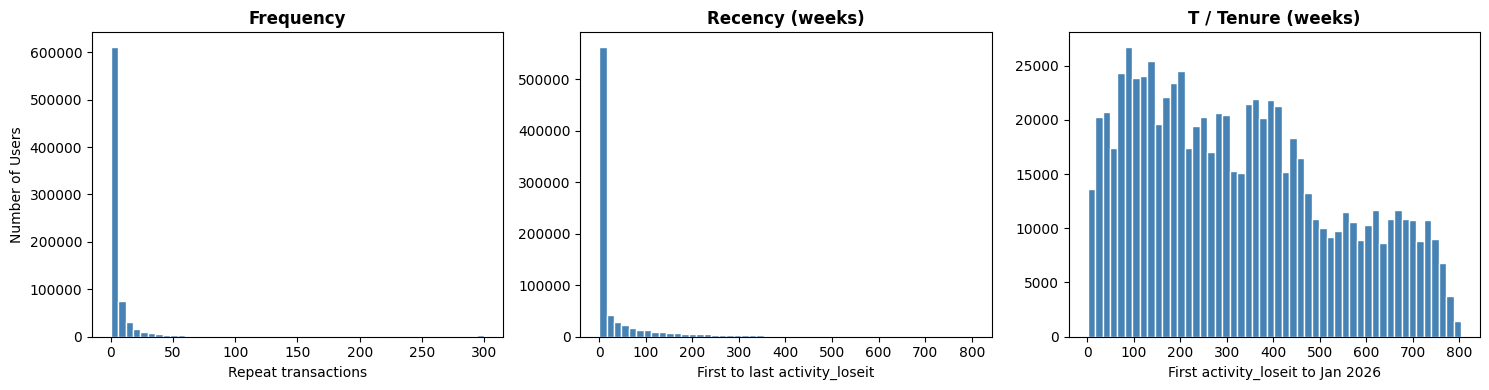

In [199]:
# frequency, recency, T distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(bgnbd_loseit['frequency'].clip(upper=300), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Frequency', fontweight='bold')
axes[0].set_xlabel('Repeat transactions')
axes[0].set_ylabel('Number of Users')

axes[1].hist(bgnbd_loseit['recency'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Recency (weeks)', fontweight='bold')
axes[1].set_xlabel('First to last activity_loseit')

axes[2].hist(bgnbd_loseit['T'], bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('T / Tenure (weeks)', fontweight='bold')
axes[2].set_xlabel('First activity_loseit to Jan 2026')

plt.tight_layout()
plt.show()

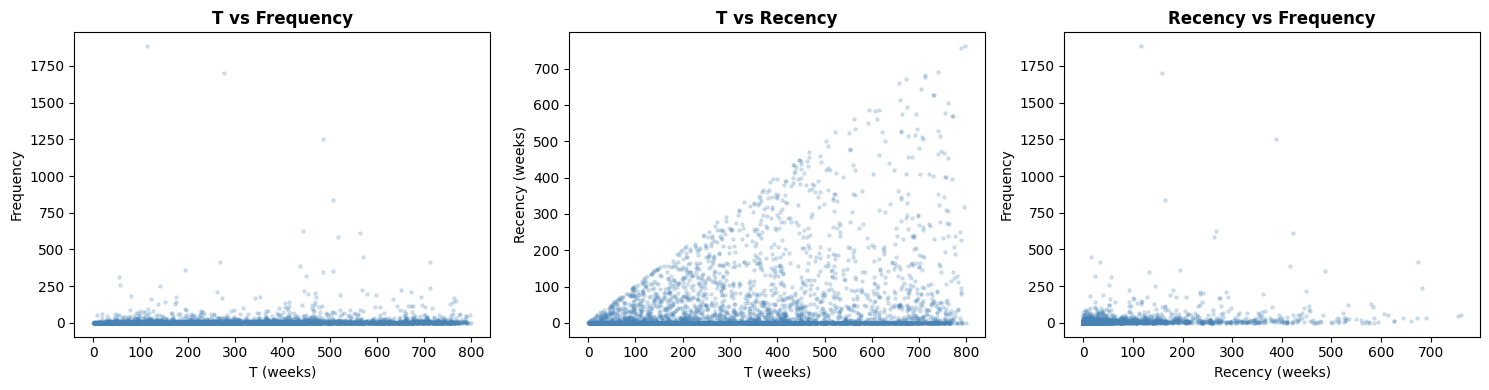

In [200]:
# pairwise scatter plots (sample 5000 users for readability)
sample = bgnbd_loseit.sample(min(5000, len(bgnbd_loseit)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(sample['T'], sample['frequency'], alpha=0.2, s=5, color='steelblue')
axes[0].set_xlabel('T (weeks)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('T vs Frequency', fontweight='bold')

axes[1].scatter(sample['T'], sample['recency'], alpha=0.2, s=5, color='steelblue')
axes[1].set_xlabel('T (weeks)')
axes[1].set_ylabel('Recency (weeks)')
axes[1].set_title('T vs Recency', fontweight='bold')

axes[2].scatter(sample['recency'], sample['frequency'], alpha=0.2, s=5, color='steelblue')
axes[2].set_xlabel('Recency (weeks)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Recency vs Frequency', fontweight='bold')

plt.tight_layout()
plt.show()

In [201]:
# summary stats
bgnbd_loseit[['frequency', 'recency', 'T']].describe().round(2)

,frequency,recency,T
count,787063.00,787063.00,787063.00
mean,9.46,39.82,326.15
std,108.07,94.96,209.94
min,0.00,0.00,0.14
25%,0.00,0.00,145.29
50%,1.00,0.00,298.86
75%,5.00,25.71,468.57
max,60108.00,802.14,804.86


**Explanation:**

The three BG/NBD input variables show similar patterns to Subreddit-1, all strongly right-skewed.

- **Frequency** (number of repeat transactions after the first): the median is 1 and the mean is 9.46. Most users have very few return visits, while a small group of highly active users extends the tail to a maximum of 60,108.

- **Recency** (weeks from first to last activity): the median is 0 weeks and the mean is 39.82 weeks. More than half of users appeared only once or within a very short time window.

- **T** (weeks from first activity to the observation end date of January 2026): the median T is 298.86 weeks (about 5.7 years) and the mean is 326.15 weeks, indicating that a large share of users joined r/loseit several years before the observation cutoff.

The scatter plots confirm that recency is always less than or equal to T for every user, satisfying the BG/NBD model constraint. The T vs. Frequency plot shows that long tenure does not necessarily lead to high activity, consistent with the pattern observed in r/learnprogramming.

### Part-7: Network Preview

In [202]:
# build reply edges from parent_id
# 't1_' prefix means reply to a comment; strip prefix to get parent comment's base id
comment_author_loseit = comments_loseit.set_index('id')['author'].to_dict()

replies_loseit = comments_loseit[comments_loseit['parent_id'].str.startswith('t1_', na=False)].copy()
replies_loseit['parent_comment_id'] = replies_loseit['parent_id'].str[3:]
replies_loseit['parent_author']     = replies_loseit['parent_comment_id'].map(comment_author_loseit)

edges_loseit = replies_loseit[['author', 'parent_author']].dropna()
edges_loseit = edges_loseit[edges_loseit['author'] != edges_loseit['parent_author']]

print(f'total reply edges:             {len(edges_loseit):,}')
print(f'unique users in reply network: {pd.concat([edges_loseit["author"], edges_loseit["parent_author"]]).nunique():,}')

total reply edges:             3,550,327
unique users in reply network: 493,377


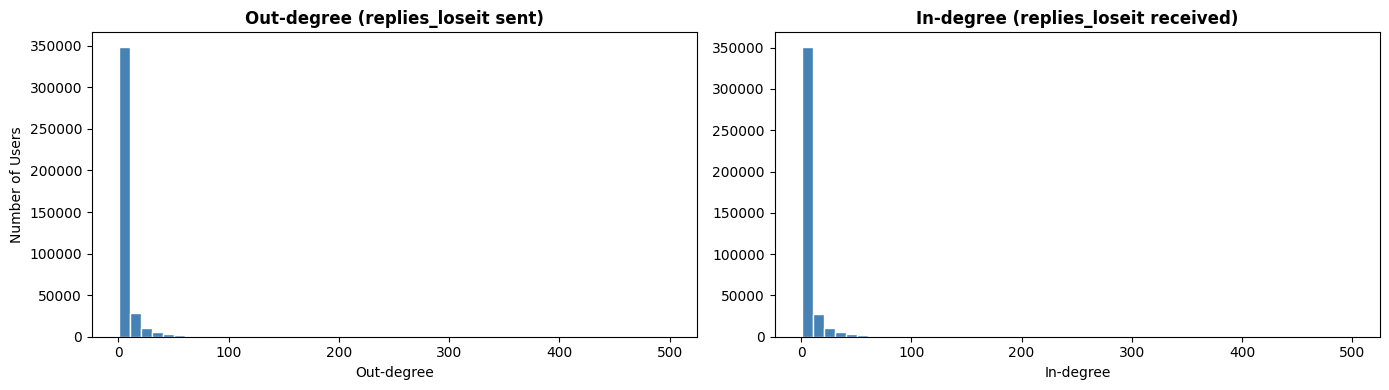

In [203]:
# in-degree and out-degree distributions
out_deg_loseit = edges_loseit['author'].value_counts()
in_deg_loseit  = edges_loseit['parent_author'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(out_deg_loseit.clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Out-degree (replies_loseit sent)', fontweight='bold')
axes[0].set_xlabel('Out-degree')
axes[0].set_ylabel('Number of Users')

axes[1].hist(in_deg_loseit.clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('In-degree (replies_loseit received)', fontweight='bold')
axes[1].set_xlabel('In-degree')

plt.tight_layout()
plt.show()

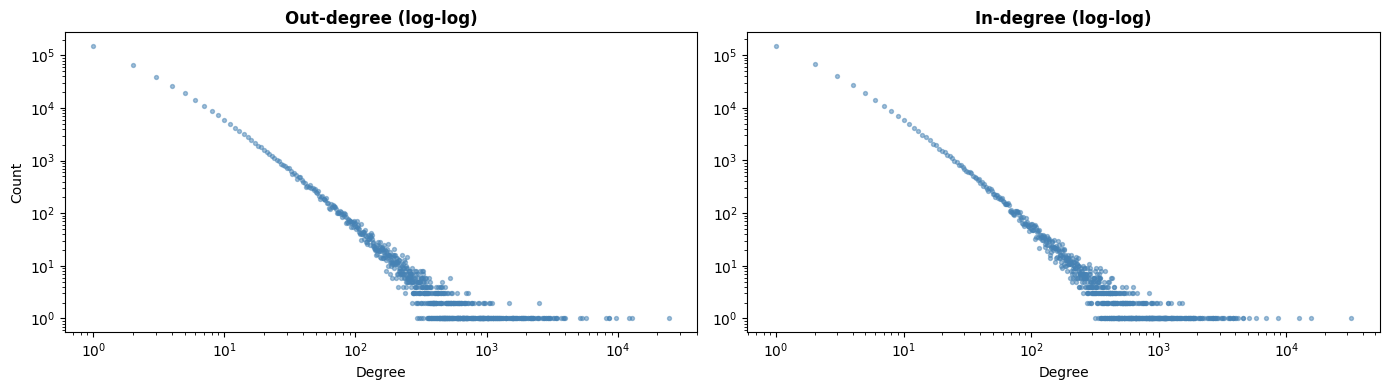

In [204]:
# log-log degree distribution (power-law check)
out_deg_counts = out_deg_loseit.value_counts().sort_index()
in_deg_counts  = in_deg_loseit.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(out_deg_counts.index, out_deg_counts.values, alpha=0.5, s=8, color='steelblue')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Out-degree (log-log)', fontweight='bold')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')

axes[1].scatter(in_deg_counts.index, in_deg_counts.values, alpha=0.5, s=8, color='steelblue')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('In-degree (log-log)', fontweight='bold')
axes[1].set_xlabel('Degree')

plt.tight_layout()
plt.show()

In [205]:
# basic network stats
all_users = pd.concat([edges_loseit['author'], edges_loseit['parent_author']])
print(f'nodes:             {all_users.nunique():,}')
print(f'edges:             {len(edges_loseit):,}')
print(f'avg out-degree:    {out_deg_loseit.mean():.2f}')
print(f'median out-degree: {out_deg_loseit.median():.0f}')
print(f'max out-degree:    {out_deg_loseit.max():,}')

nodes:             493,377
edges:             3,550,327
avg out-degree:    8.74
median out-degree: 2
max out-degree:    24,464


**Explanation:**

- **The reply network** contains 3,550,327 directed edges connecting 493,377 unique users. Each edge represents one user directly replying to another user's comment. Out of 792,129 qualifying users, about 62.3% appear in the reply network, meaning a substantial portion of users only posted top-level content without engaging in direct reply exchanges.

- **The out-degree distribution** (replies sent) and **in-degree distribution** (replies received) are both heavily right-skewed. The average out-degree is 8.74, but the median is only 2, indicating that most users sent very few replies while a small number of users were extremely active. The most active replier sent 24,464 replies.

- **The log-log degree distribution plots** show an approximately linear trend for both in-degree and out-degree, which is consistent with a power-law distribution. This is a common structural property of social networks and suggests that the r/loseit reply network has the same "hub" structure as r/learnprogramming, with a small number of highly connected users and a large majority with minimal connectivity.

#### Part-7: Network Preview 2.0

r/loseit — 392,074 / 761,112 users in network (51.5%)
  Mean out-degree    : 6.88
  Mean in-degree     : 6.56
  Mean k-core        : 5.01
  Mean clustering    : 0.0590
  Mean community size: 104034.5


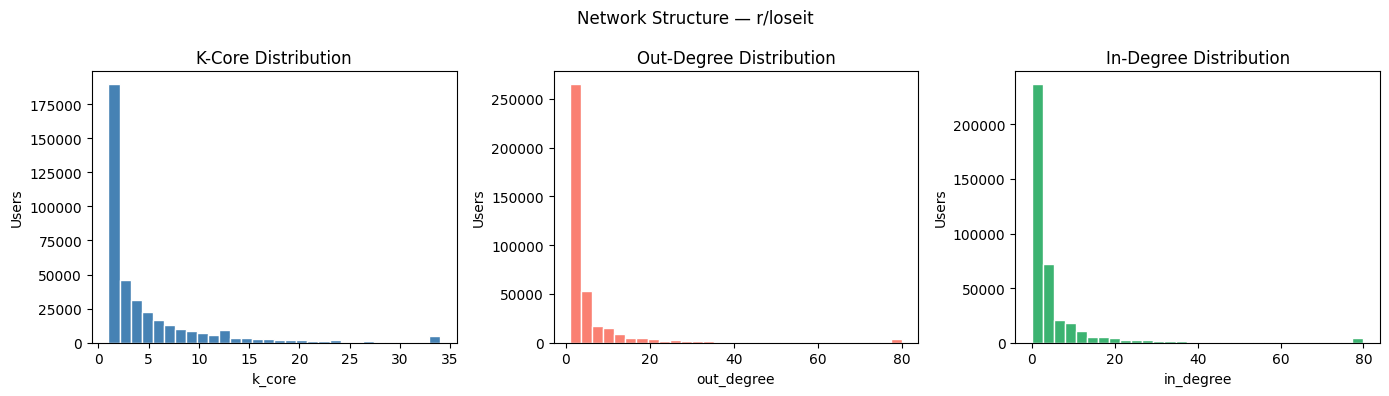

In [ ]:
# Network structure — r/loseit
import pandas as pd, numpy as np, matplotlib.pyplot as plt

feat   = pd.read_parquet('../data/processed_data/features_net_loseit.parquet')
in_net = feat[feat['out_degree'] > 0]
pct    = len(in_net) / len(feat) * 100

print(f'r/loseit — {len(in_net):,} / {len(feat):,} users in network ({pct:.1f}%)')
print(f'  Mean out-degree    : {in_net["out_degree"].mean():.2f}')
print(f'  Mean in-degree     : {in_net["in_degree"].mean():.2f}')
print(f'  Mean k-core        : {in_net["k_core"].mean():.2f}')
print(f'  Mean clustering    : {in_net["clustering_coef"].mean():.4f}')
print(f'  Mean community size: {in_net["community_size"].mean():.1f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Network Structure — r/loseit', fontsize=12)

for ax, (col, title, color) in zip(axes, [
    ('k_core',     'K-Core Distribution',    'steelblue'),
    ('out_degree', 'Out-Degree Distribution', 'salmon'),
    ('in_degree',  'In-Degree Distribution',  'mediumseagreen'),
]):
    vals = in_net[col].clip(upper=in_net[col].quantile(0.99))
    ax.hist(vals, bins=30, color=color, edgecolor='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Users')
    ax.set_title(title)

plt.tight_layout()
plt.show()


## Subreddit-3: depression

### Part-1: Data Overview

In [206]:
DATA_DIR = '/Users/yangshuting/Desktop/UChicago/courses/spring_2026/MACS_30200_Research_Design/final_proposal/data/raw_data/depression/'
POSTS_PATH    = DATA_DIR + 'r_depression_posts.jsonl'
COMMENTS_PATH = DATA_DIR + 'r_depression_comments.jsonl'
OBS_END = pd.Timestamp('2026-01-01', tz='UTC')

In [207]:
# load posts - keep only needed columns
POSTS_COLS = ['author', 'created_utc', 'id', 'title', 'selftext', 'score', 'num_comments']

posts = []
with open(POSTS_PATH) as f:
    for line in f:
        d = json.loads(line)
        posts.append({k: d.get(k) for k in POSTS_COLS})

posts_dep = pd.DataFrame(posts)
n_posts_raw = len(posts_dep)
posts_dep.shape

(1946351, 7)

In [208]:
# load comments - keep only needed columns
COMMENTS_COLS = ['author', 'created_utc', 'id', 'body', 'score', 'parent_id', 'link_id']

comments = []
with open(COMMENTS_PATH) as f:
    for line in f:
        d = json.loads(line)
        comments.append({k: d.get(k) for k in COMMENTS_COLS})

comments_dep = pd.DataFrame(comments)
n_comments_raw = len(comments_dep)
comments_dep.shape

(6774799, 7)

In [209]:
# get an overview of posts
posts_dep.head()

,author,created_utc,id,title,selftext,score,num_comments
0,[deleted],1230773002,7mqco,"Girls, the future and some other stuff.",[deleted],1,0
1,HappyRabbit,1230773772,7mqdw,Girls and stuff.,[removed],1,1
2,[deleted],1230780179,7mqo7,I had plans to go out to one or more parties t...,,7,2
3,[deleted],1230784330,7mqur,Nearly all of my friends are out for the night...,,6,7
4,[deleted],1230786778,7mqyx,"I can't talk to girls, or really anyone in per...",[deleted],7,11


In [210]:
# get an overview of comments
comments_dep.head()

,author,created_utc,id,body,score,parent_id,link_id
0,HappyRabbit,1230776046,7xa0,I have always been a geek. Ever since I rememb...,1,t3_7mqdw,t3_7mqdw
1,[deleted],1230780294,7y9n,Haha the picture made me smile,2,t3_7mqo7,t3_7mqo7
2,[deleted],1230786613,7zel,[deleted],1,t3_7mqur,t3_7mqur
3,cluuxz,1230786885,7zgf,"It's like, I can go up to people and know exac...",4,t3_7mqyx,t3_7mqyx
4,cfabbro,1230786916,7zgn,"Do what makes you feel good, comfortable, or s...",6,t3_7mqur,t3_7mqur


In [211]:
# check data types
posts_dep.dtypes

author          object
created_utc      int64
id              object
title           object
selftext        object
score            int64
num_comments     int64
dtype: object

### Part-2: Data Cleaning

#### 2.1 Remove missing values

In [212]:
# check missing values
null_posts    = posts_dep.isnull().sum()
null_comments = comments_dep.isnull().sum()
print('=== Posts ===')
print(null_posts)
print('\n=== Comments ===')
print(null_comments)

=== Posts ===
author          0
created_utc     0
id              0
title           0
selftext        0
score           0
num_comments    0
dtype: int64

=== Comments ===
author         0
created_utc    0
id             0
body           0
score          0
parent_id      0
link_id        0
dtype: int64


In [213]:
# drop columns that have at least 30% missing values
posts_dep.drop(columns=posts_dep.columns[null_posts > len(posts_dep) * 0.3], inplace=True)
comments_dep.drop(columns=comments_dep.columns[null_comments > len(comments_dep) * 0.3], inplace=True)

# check remaining columns
print('posts columns:', posts_dep.columns.tolist())
print('comments columns:', comments_dep.columns.tolist())

posts columns: ['author', 'created_utc', 'id', 'title', 'selftext', 'score', 'num_comments']
comments columns: ['author', 'created_utc', 'id', 'body', 'score', 'parent_id', 'link_id']


The same result is observed as in Subreddit-1 and Subreddit-2: all selected columns have zero missing values. The core Reddit fields loaded are always present in the source data, so no imputation or column removal is needed.

#### 2.2 Remove duplicates

In [214]:
# check duplicate content: same user posting identical text
# posts: same author + same title; comments: same author + same body
dup_posts    = posts_dep.duplicated(subset=['author', 'title'], keep=False).sum()
dup_comments = comments_dep.duplicated(subset=['author', 'body'], keep=False).sum()

print(f'duplicate posts (same author + title):   {dup_posts:,}')
print(f'duplicate comments (same author + body): {dup_comments:,}')

duplicate posts (same author + title):   154,956
duplicate comments (same author + body): 1,261,778


In [215]:
# drop duplicates, keep first occurrence
posts_dep    = posts_dep.drop_duplicates(subset=['author', 'title'], keep='first').reset_index(drop=True)
comments_dep = comments_dep.drop_duplicates(subset=['author', 'body'],  keep='first').reset_index(drop=True)

n_posts_after_dedup    = len(posts_dep)
n_comments_after_dedup = len(comments_dep)
print(f'posts after dedup:    {n_posts_after_dedup:,}')
print(f'comments after dedup: {n_comments_after_dedup:,}')

posts after dedup:    1,821,498
comments after dedup: 5,531,229


#### 2.3 Remove user-deleted accounts

In [216]:
# check [deleted] author proportion
print('=== Posts ===')
print(f'total: {len(posts_dep):,}')
print(f'[deleted]: {(posts_dep["author"] == "[deleted]").sum():,}  ({(posts_dep["author"] == "[deleted]").mean()*100:.1f}%)')
print(f'[removed]: {(posts_dep["author"] == "[removed]").sum():,}')

print('\n=== Comments ===')
print(f'total: {len(comments_dep):,}')
print(f'[deleted]: {(comments_dep["author"] == "[deleted]").sum():,}  ({(comments_dep["author"] == "[deleted]").mean()*100:.1f}%)')
print(f'[removed]: {(comments_dep["author"] == "[removed]").sum():,}')

=== Posts ===
total: 1,821,498
[deleted]: 490,574  (26.9%)
[removed]: 0

=== Comments ===
total: 5,531,229
[deleted]: 208,089  (3.8%)
[removed]: 0


In [217]:
# remove user-deleted accounts
posts_dep    = posts_dep[~posts_dep['author'].isin(['[deleted]', '[removed]'])].reset_index(drop=True)
comments_dep = comments_dep[~comments_dep['author'].isin(['[deleted]', '[removed]'])].reset_index(drop=True)

n_posts_after_deleted    = len(posts_dep)
n_comments_after_deleted = len(comments_dep)
print(f'posts after filtering:    {n_posts_after_deleted:,}')
print(f'comments after filtering: {n_comments_after_deleted:,}')

posts after filtering:    1,330,924
comments after filtering: 5,323,140


As in Subreddit-1 and Subreddit-2, `[removed]` is not expected to appear in the `author` column. Moderator removals typically affect only the content fields (`selftext`/`body`), not the `author` field. Verify this against the output above before proceeding.

#### 2.4 Remove mod-deleted post and comment content

In [218]:
# check [deleted] / [removed] text in content fields
print(f'posts with [deleted] selftext:  {(posts_dep["selftext"] == "[deleted]").sum():,}')
print(f'posts with [removed] selftext:  {(posts_dep["selftext"] == "[removed]").sum():,}')
print(f'comments with [deleted] body:   {(comments_dep["body"] == "[deleted]").sum():,}')
print(f'comments with [removed] body:   {(comments_dep["body"] == "[removed]").sum():,}')

posts with [deleted] selftext:  43
posts with [removed] selftext:  174,285
comments with [deleted] body:   14
comments with [removed] body:   12


In [219]:
# replace [deleted] / [removed] text with NaN
posts_dep['selftext'] = posts_dep['selftext'].replace(['[deleted]', '[removed]'], None)
comments_dep['body']  = comments_dep['body'].replace(['[deleted]', '[removed]'], None)

# re-check missing after replacing
print(f'selftext missing after cleaning: {posts_dep["selftext"].isnull().sum():,}')
print(f'body missing after cleaning:     {comments_dep["body"].isnull().sum():,}')

selftext missing after cleaning: 174,328
body missing after cleaning:     26


#### 2.5 Remove bots

In [220]:
# check top 30 most active commenters to identify bots
top_commenters = comments_dep['author'].value_counts().head(30)
top_commenters

author
JesusAndSoda            16594
AnotherTrowaway12       13596
SQLwitch                 5613
K4yr0                    3848
SH2355                   3604
poisontongue             3136
Alexanderismyname        2503
mobiuschick              2459
numberfivedream          2346
kaytiejay25              2341
skyqween                 2261
LostLetterbox            2226
ihitokage                2147
mytwocats11              2127
bronzebeagle             2034
mcfattykins              1980
h3llios                  1953
catsRawesome123          1933
Bhruic                   1899
maddiokii                1873
the_harassed             1767
IMainJannaxxx            1706
FamishedHippopotamus     1665
drauch52                 1616
cacktastic               1595
phelbooth                1563
throwawaymdd7            1548
RSFan1234                1504
TaurineLine719           1455
glendon24                1436
Name: count, dtype: int64

In [221]:
# define known bots and remove them
BOTS = [
    'AutoModerator', 'BotDefense', 'RepostSleuthBot', 'snapshillbot',
    'WikiTextBot', 'LinkifyBot', 'TweetPoster', 'imgurtranscriber',
    'MAGIC_EYE_BOT', 'RemindMeBot', 'haikusbot', 'converter-bot'
]

posts_dep    = posts_dep[~posts_dep['author'].isin(BOTS)].reset_index(drop=True)
comments_dep = comments_dep[~comments_dep['author'].isin(BOTS)].reset_index(drop=True)

n_posts_after_bots    = len(posts_dep)
n_comments_after_bots = len(comments_dep)
print(f'posts after bot removal:    {n_posts_after_bots:,}')
print(f'comments after bot removal: {n_comments_after_bots:,}')

posts after bot removal:    1,330,924
comments after bot removal: 5,323,107


#### 2.6 User activity records and low-activity filtering

In [222]:
# convert timestamps
posts_dep['created_utc']    = pd.to_datetime(posts_dep['created_utc'], unit='s', utc=True)
comments_dep['created_utc'] = pd.to_datetime(comments_dep['created_utc'], unit='s', utc=True)

In [223]:
# each post/comment = one transaction (following BG/NBD convention)
activity_dep = pd.concat([
    posts_dep[['author', 'created_utc']],
    comments_dep[['author', 'created_utc']]
], ignore_index=True).sort_values('created_utc').reset_index(drop=True)

print(f'total activity_dep records: {len(activity_dep):,}')

total activity_dep records: 6,654,031


In [224]:
# compute per-user activity_dep stats
user_stats_dep = activity_dep.groupby('author').agg(
    n_activity = ('created_utc', 'count'),
    first_post = ('created_utc', 'min'),
    last_post  = ('created_utc', 'max')
).reset_index()

print(f'total unique users: {len(user_stats_dep):,}')
user_stats_dep.head()

total unique users: 1,234,157


,author,n_activity,first_post,last_post
0,---,5,2010-11-17 01:11:39+00:00,2011-08-15 07:16:18+00:00
1,----------------_--_,1,2016-08-06 05:39:52+00:00,2016-08-06 05:39:52+00:00
2,--------uuhhhhh,3,2019-04-23 04:30:21+00:00,2019-06-26 00:59:47+00:00
3,-------RS--------,31,2019-09-03 07:44:45+00:00,2019-11-17 23:31:26+00:00
4,-------dingo,1,2020-05-26 17:35:00+00:00,2020-05-26 17:35:00+00:00


In [225]:
# compute the bottom 5% activity_dep threshold (calculated per subreddit)
threshold = int(user_stats_dep['n_activity'].quantile(0.05))
print(f'bottom 5% threshold: {threshold} activities')
print(f'users before filter: {len(user_stats_dep):,}')

bottom 5% threshold: 1 activities
users before filter: 1,234,157


In [226]:
# drop users below the threshold
user_stats_dep = user_stats_dep[user_stats_dep['n_activity'] >= threshold].reset_index(drop=True)
qualifying_users_dep = set(user_stats_dep['author'])

# filter activity_dep, posts_dep, comments_dep to qualifying users only
activity_dep    = activity_dep[activity_dep['author'].isin(qualifying_users_dep)].reset_index(drop=True)
posts_dep    = posts_dep[posts_dep['author'].isin(qualifying_users_dep)].reset_index(drop=True)
comments_dep = comments_dep[comments_dep['author'].isin(qualifying_users_dep)].reset_index(drop=True)

print(f'qualifying users:   {len(user_stats_dep):,}')
print(f'posts (final):      {len(posts_dep):,}')
print(f'comments (final):   {len(comments_dep):,}')

qualifying users:   1,234,157
posts (final):      1,330,924
comments (final):   5,323,107


#### 2.7 Cleaned data overview

In [227]:
# cleaning steps summary
summary = pd.DataFrame({
    'Step': [
        'Raw posts', 'Raw comments',
        'After removing duplicates (posts)', 'After removing duplicates (comments)',
        'After removing [deleted] authors (posts)', 'After removing [deleted] authors (comments)',
        'After removing bots (posts)', 'After removing bots (comments)',
        'Final posts (qualifying users only)', 'Final comments (qualifying users only)',
        'Qualifying users'
    ],
    'Count': [
        n_posts_raw, n_comments_raw,
        n_posts_after_dedup, n_comments_after_dedup,
        n_posts_after_deleted, n_comments_after_deleted,
        n_posts_after_bots, n_comments_after_bots,
        len(posts_dep), len(comments_dep),
        len(user_stats_dep)
    ]
})
summary

,Step,Count
0,Raw posts,1946351
1,Raw comments,6774799
2,After removing duplicates (posts),1821498
3,After removing duplicates (comments),5531229
4,After removing [deleted] authors (posts),1330924
5,After removing [deleted] authors (comments),5323140
6,After removing bots (posts),1330924
7,After removing bots (comments),5323107
8,Final posts (qualifying users only),1330924
9,Final comments (qualifying users only),5323107


In [228]:
# final cleaned data summary
print('=== Final Cleaned Data ===')
print(f'posts_dep:    {len(posts_dep):,} rows  -- cleaned posts with full text and metadata (qualifying users only)')
print(f'comments_dep: {len(comments_dep):,} rows  -- cleaned comments with full text and metadata (qualifying users only)')
print(f'user_stats_dep:  {len(user_stats_dep):,} rows  -- per-user activity_dep stats (n_activity, first_post, last_post)')
print()
print('posts_dep and comments_dep are the main data sources for NLP features and network construction.')
print('user_stats_dep is used to compute BG/NBD inputs (frequency, recency, T) per user.')

=== Final Cleaned Data ===
posts_dep:    1,330,924 rows  -- cleaned posts with full text and metadata (qualifying users only)
comments_dep: 5,323,107 rows  -- cleaned comments with full text and metadata (qualifying users only)
user_stats_dep:  1,234,157 rows  -- per-user activity_dep stats (n_activity, first_post, last_post)

posts_dep and comments_dep are the main data sources for NLP features and network construction.
user_stats_dep is used to compute BG/NBD inputs (frequency, recency, T) per user.


In [229]:
# cleaned data overview
print(f'posts_dep:    {posts_dep.shape}')
print(f'comments_dep: {comments_dep.shape}')
print(f'user_stats_dep:  {user_stats_dep.shape}')
print()
display(posts_dep.head())
display(comments_dep.head())

posts_dep:    (1330924, 7)
comments_dep: (5323107, 7)
user_stats_dep:  (1234157, 4)



,author,created_utc,id,title,selftext,score,num_comments
0,HappyRabbit,2009-01-01 01:36:12+00:00,7mqdw,Girls and stuff.,None,1,1
1,Ostrich159,2009-01-01 05:41:54+00:00,7mr2a,Another Offshoot: Anxiety/Panic Reddit for any...,,4,0
2,OctopusMan,2009-01-01 09:38:10+00:00,7mrp0,Tired of being lonely.,,12,14
3,i_love_u,2009-01-01 10:34:46+00:00,7mru2,i love you :),None,1,0
4,Ostrich159,2009-01-02 01:08:00+00:00,7mv8e,Proper sleep is an important part of recovery.,,11,0


,author,created_utc,id,body,score,parent_id,link_id
0,HappyRabbit,2009-01-01 02:14:06+00:00,7xa0,I have always been a geek. Ever since I rememb...,1,t3_7mqdw,t3_7mqdw
1,cluuxz,2009-01-01 05:14:45+00:00,7zgf,"It's like, I can go up to people and know exac...",4,t3_7mqyx,t3_7mqyx
2,cfabbro,2009-01-01 05:15:16+00:00,7zgn,"Do what makes you feel good, comfortable, or s...",6,t3_7mqur,t3_7mqur
3,Ostrich159,2009-01-01 05:35:23+00:00,7zo9,I'm home by myself as well. Don't forget that ...,6,t3_7mqo7,t3_7mqo7
4,redmosquito,2009-01-01 06:01:22+00:00,7zxq,"I know it can be really hard, but you have to ...",4,t1_7zgf,t3_7mqyx


### Part-3: User Activity

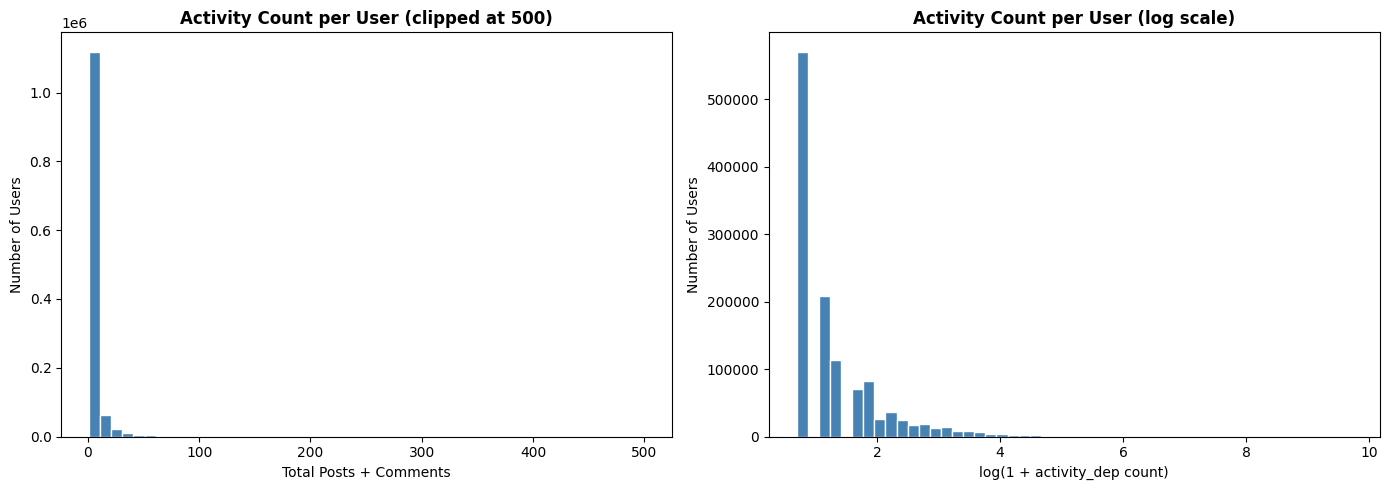

In [230]:
# activity_dep count per user distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_stats_dep['n_activity'].clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Activity Count per User (clipped at 500)', fontweight='bold')
axes[0].set_xlabel('Total Posts + Comments')
axes[0].set_ylabel('Number of Users')

axes[1].hist(np.log1p(user_stats_dep['n_activity']), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Activity Count per User (log scale)', fontweight='bold')
axes[1].set_xlabel('log(1 + activity_dep count)')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

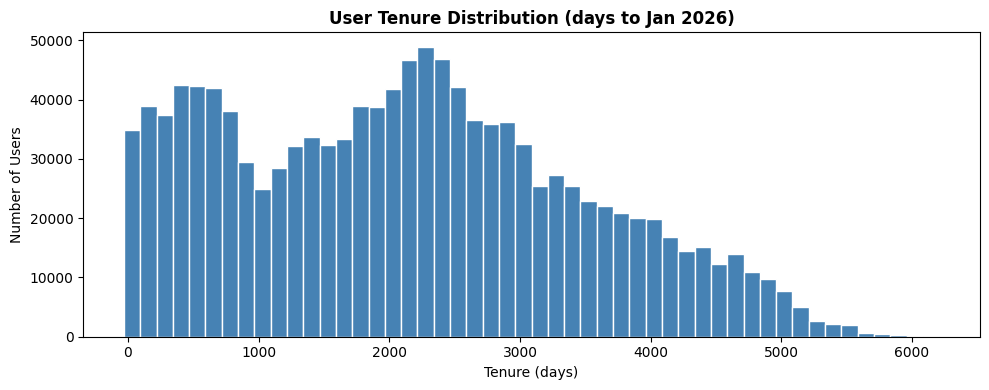

In [231]:
# user tenure distribution
user_stats_dep['tenure_days'] = (OBS_END - user_stats_dep['first_post']).dt.days

plt.figure(figsize=(10, 4))
plt.hist(user_stats_dep['tenure_days'], bins=50, color='steelblue', edgecolor='white')
plt.title('User Tenure Distribution (days to Jan 2026)', fontweight='bold')
plt.xlabel('Tenure (days)')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

In [232]:
# summary stats
user_stats_dep[['n_activity', 'tenure_days']].describe().round(1)

,n_activity,tenure_days
count,1234157.0,1234157.0
mean,5.4,2134.9
std,29.7,1333.2
min,1.0,-30.0
25%,1.0,986.0
50%,2.0,2113.0
75%,4.0,3049.0
max,16594.0,6208.0


**Note:** Same as Subreddit-1 and Subreddit-2, any negative minimum tenure is a data collection artifact caused by records from January 2026 falling after the observation cutoff. These users are automatically excluded in Part 6 by the T > 0 filter and do not affect the modeling.

**Explanation:**

- **The activity distribution** is strongly right-skewed. The median user has only 2 total posts or comments, while the mean is 5.4. A small number of highly active users raise the mean considerably, with the most active user contributing 16,594 interactions. This pattern is consistent with what was observed in r/learnprogramming and r/loseit and is typical of large online communities.

- **User tenure** also varies widely. The median tenure is about 2,113 days (roughly 5.8 years) and the mean is 2,135 days, suggesting that r/depression has accumulated a substantial base of long-term members alongside many occasional visitors.

### Part-4: Community Activity

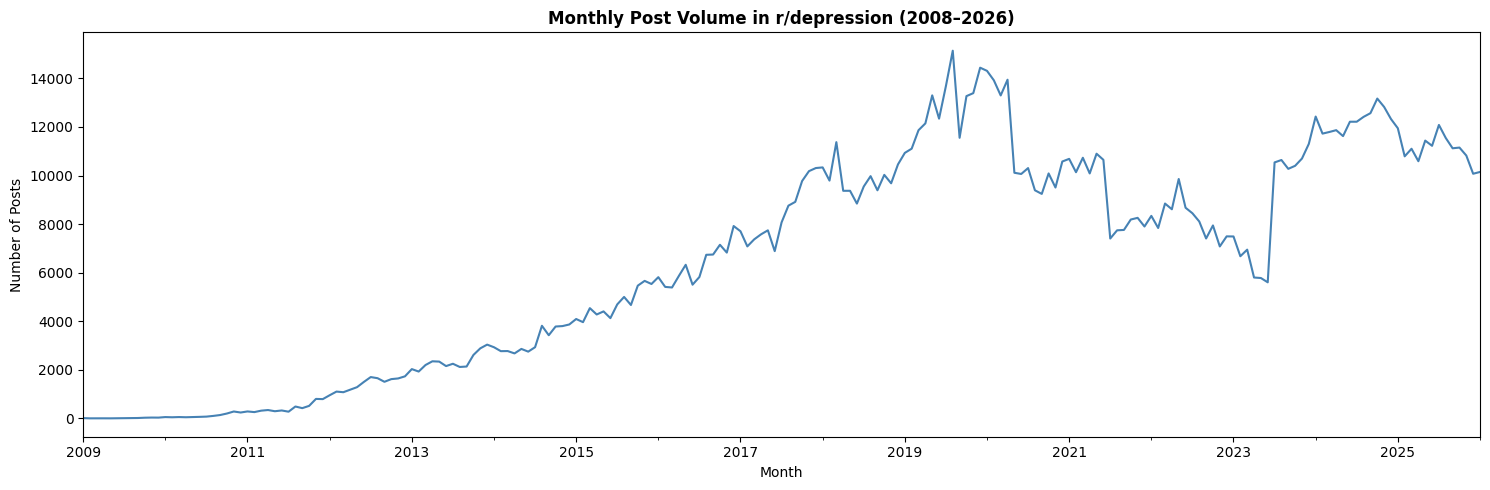

In [233]:
# monthly post volume over time
monthly_posts = posts_dep.groupby(posts_dep['created_utc'].dt.to_period('M')).size()

plt.figure(figsize=(15, 5))
monthly_posts.plot(color='steelblue', lw=1.5)
plt.title('Monthly Post Volume in r/depression (2008–2026)', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()

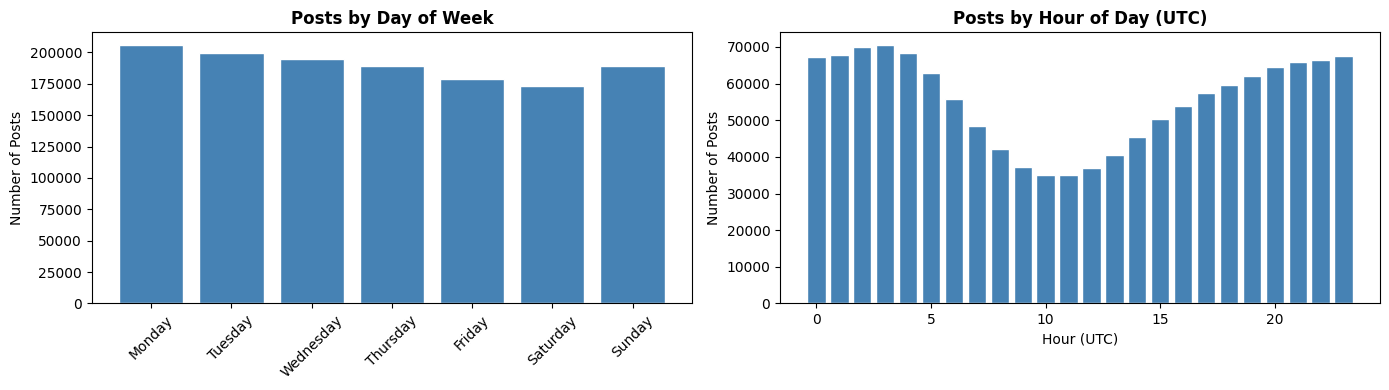

In [234]:
# post volume by day of week and hour of day
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily  = posts_dep['created_utc'].dt.day_name().value_counts().reindex(day_order)
hourly = posts_dep['created_utc'].dt.hour.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(daily.index, daily.values, color='steelblue', edgecolor='white')
axes[0].set_title('Posts by Day of Week', fontweight='bold')
axes[0].set_ylabel('Number of Posts')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
axes[1].set_title('Posts by Hour of Day (UTC)', fontweight='bold')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Number of Posts')

plt.tight_layout()
plt.show()

**Explanation:**

- **The monthly post volume chart** shows that r/depression has grown steadily since its founding around 2008, with activity increasing over time and remaining consistently high through early 2026.
- **The day-of-week bar chart** shows that posting is distributed fairly evenly across the week, with no strong weekday or weekend preference. This may reflect the nature of the community, where users seek support regardless of the day.
- **The hourly bar chart** (UTC) shows that activity is concentrated during certain daytime hours, reflecting the geographic distribution of the community's active user base.

### Part-5: Content Overview

In [235]:
# text posts vs link posts
has_selftext = posts_dep['selftext'].notna() & (posts_dep['selftext'].str.strip() != '')
print(f'text posts: {has_selftext.sum():,}  ({has_selftext.mean()*100:.1f}%)')
print(f'link posts: {(~has_selftext).sum():,}  ({(~has_selftext).mean()*100:.1f}%)')

text posts: 1,131,370  (85.0%)
link posts: 199,554  (15.0%)


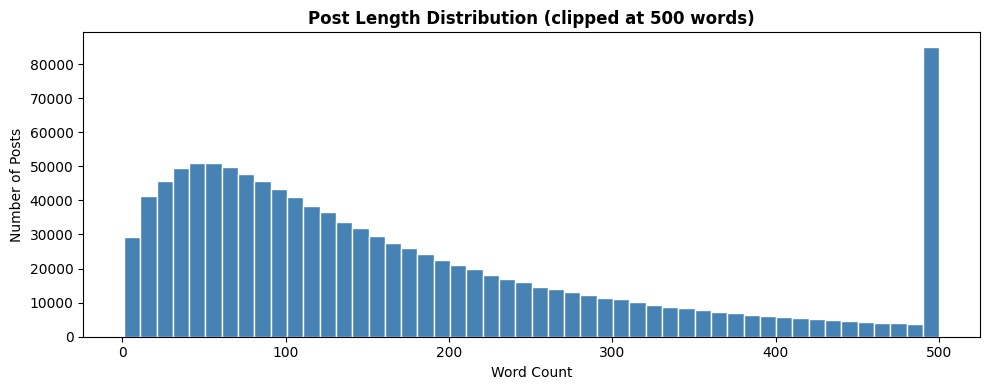

median: 129 words  |  mean: 197 words


In [236]:
# selftext length distribution (text posts only)
text_posts = posts_dep[has_selftext].copy()
text_posts['selftext_words'] = text_posts['selftext'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
plt.hist(text_posts['selftext_words'].clip(upper=500), bins=50, color='steelblue', edgecolor='white')
plt.title('Post Length Distribution (clipped at 500 words)', fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()

print(f'median: {text_posts["selftext_words"].median():.0f} words  |  mean: {text_posts["selftext_words"].mean():.0f} words')

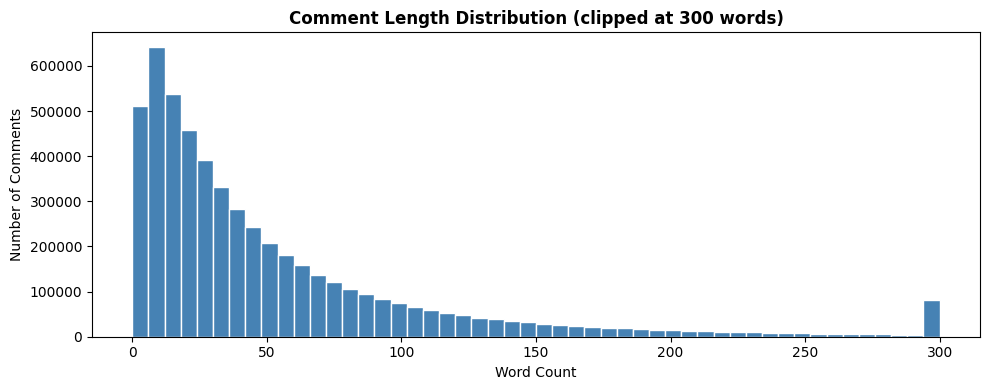

median: 32 words  |  mean: 54 words


In [237]:
# comment body length distribution
valid_comments = comments_dep[comments_dep['body'].notna()].copy()
valid_comments['body_words'] = valid_comments['body'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
plt.hist(valid_comments['body_words'].clip(upper=300), bins=50, color='steelblue', edgecolor='white')
plt.title('Comment Length Distribution (clipped at 300 words)', fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.show()

print(f'median: {valid_comments["body_words"].median():.0f} words  |  mean: {valid_comments["body_words"].mean():.0f} words')

**Note:** Same as Subreddit-1 and Subreddit-2, the spikes at 500 words (posts) and 300 words (comments) are a `.clip()` artifact, not real data anomalies.

**Explanation:**

r/depression has a high share of text posts at 85.0%, with 15.0% being link posts. This is close to r/learnprogramming (89.4%) and suggests that users primarily come to the community to share personal experiences and seek support through written posts rather than linking external content.

- **Among text posts**, the median length is 129 words and the mean is 197 words. Posts tend to be moderately detailed, which likely reflects the personal nature of mental health disclosures.
- **Comments** have a median of 32 words and a mean of 54 words, similar to the levels observed in the other two subreddits. Both distributions are right-skewed.

### Part-6: BG/NBD Inputs

In [238]:
# compute BG/NBD inputs per qualifying user
bgnbd_dep = user_stats_dep.copy()
bgnbd_dep['T']         = (OBS_END - bgnbd_dep['first_post']).dt.days / 7
bgnbd_dep['recency']   = (bgnbd_dep['last_post'] - bgnbd_dep['first_post']).dt.days / 7
bgnbd_dep['frequency'] = bgnbd_dep['n_activity'] - 1

bgnbd_dep = bgnbd_dep[bgnbd_dep['T'] > 0].reset_index(drop=True)
print(f'users for BG/NBD modeling: {len(bgnbd_dep):,}')
bgnbd_dep[['frequency', 'recency', 'T']].head()

users for BG/NBD modeling: 1,225,950


,frequency,recency,T
0,4,38.714286,789.000000
1,0,0.000000,490.571429
2,2,9.000000,349.142857
3,30,10.714286,330.142857
4,0,0.000000,292.142857


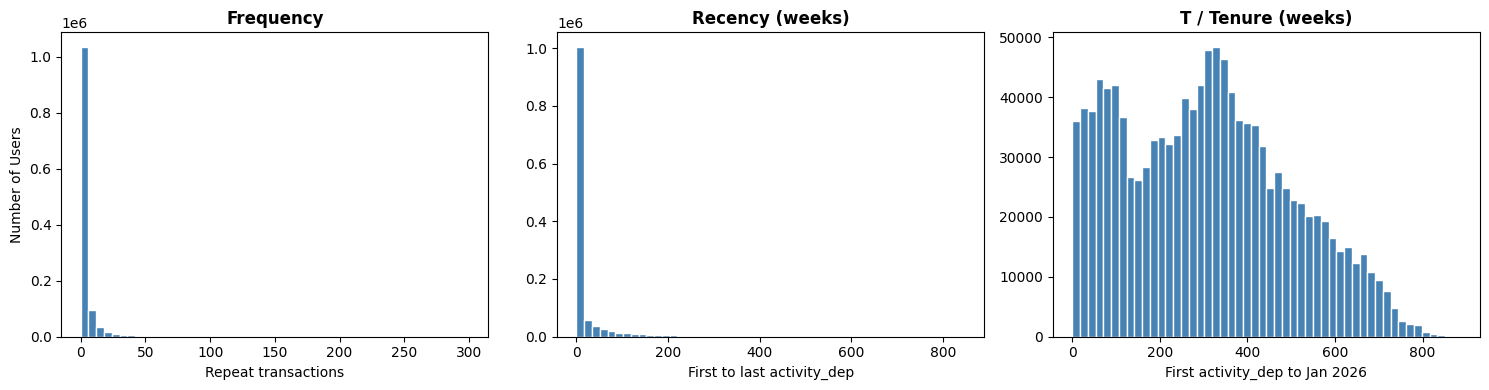

In [239]:
# frequency, recency, T distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(bgnbd_dep['frequency'].clip(upper=300), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Frequency', fontweight='bold')
axes[0].set_xlabel('Repeat transactions')
axes[0].set_ylabel('Number of Users')

axes[1].hist(bgnbd_dep['recency'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Recency (weeks)', fontweight='bold')
axes[1].set_xlabel('First to last activity_dep')

axes[2].hist(bgnbd_dep['T'], bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('T / Tenure (weeks)', fontweight='bold')
axes[2].set_xlabel('First activity_dep to Jan 2026')

plt.tight_layout()
plt.show()

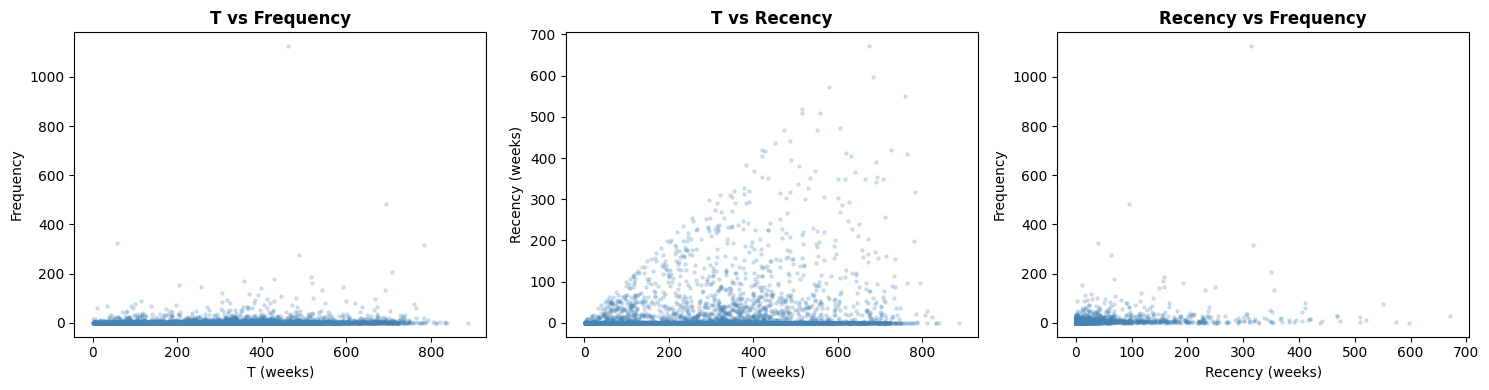

In [240]:
# pairwise scatter plots (sample 5000 users for readability)
sample = bgnbd_dep.sample(min(5000, len(bgnbd_dep)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(sample['T'], sample['frequency'], alpha=0.2, s=5, color='steelblue')
axes[0].set_xlabel('T (weeks)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('T vs Frequency', fontweight='bold')

axes[1].scatter(sample['T'], sample['recency'], alpha=0.2, s=5, color='steelblue')
axes[1].set_xlabel('T (weeks)')
axes[1].set_ylabel('Recency (weeks)')
axes[1].set_title('T vs Recency', fontweight='bold')

axes[2].scatter(sample['recency'], sample['frequency'], alpha=0.2, s=5, color='steelblue')
axes[2].set_xlabel('Recency (weeks)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Recency vs Frequency', fontweight='bold')

plt.tight_layout()
plt.show()

In [241]:
# summary stats
bgnbd_dep[['frequency', 'recency', 'T']].describe().round(2)

,frequency,recency,T
count,1225950.00,1225950.00,1225950.00
mean,4.41,18.95,307.04
std,29.77,56.80,189.43
min,0.00,0.00,0.14
25%,0.00,0.00,145.29
50%,1.00,0.00,303.57
75%,3.00,4.57,436.57
max,16593.00,847.86,886.86


**Explanation:**

The three BG/NBD input variables show similar patterns to Subreddit-1 and Subreddit-2, all strongly right-skewed.

- **Frequency** (number of repeat transactions after the first): the median is 1 and the mean is 4.41. Most users have very few return visits, while a small group of highly active users extends the tail to a maximum of 16,593.

- **Recency** (weeks from first to last activity): the median is 0 weeks and the mean is 18.95 weeks. More than half of users appeared only once or within a very short time window.

- **T** (weeks from first activity to the observation end date of January 2026): the median T is 303.57 weeks (about 5.8 years) and the mean is 307.04 weeks, indicating that a large share of users joined r/depression several years before the observation cutoff.

The scatter plots confirm that recency is always less than or equal to T for every user, satisfying the BG/NBD model constraint. The T vs. Frequency plot shows that long tenure does not necessarily lead to high activity, consistent with the pattern observed in the other subreddits.

### Part-7: Network Preview

In [242]:
# build reply edges from parent_id
# 't1_' prefix means reply to a comment; strip prefix to get parent comment's base id
comment_author_dep = comments_dep.set_index('id')['author'].to_dict()

replies_dep = comments_dep[comments_dep['parent_id'].str.startswith('t1_', na=False)].copy()
replies_dep['parent_comment_id'] = replies_dep['parent_id'].str[3:]
replies_dep['parent_author']     = replies_dep['parent_comment_id'].map(comment_author_dep)

edges_dep = replies_dep[['author', 'parent_author']].dropna()
edges_dep = edges_dep[edges_dep['author'] != edges_dep['parent_author']]

print(f'total reply edges:             {len(edges_dep):,}')
print(f'unique users in reply network: {pd.concat([edges_dep["author"], edges_dep["parent_author"]]).nunique():,}')

total reply edges:             2,056,916
unique users in reply network: 586,867


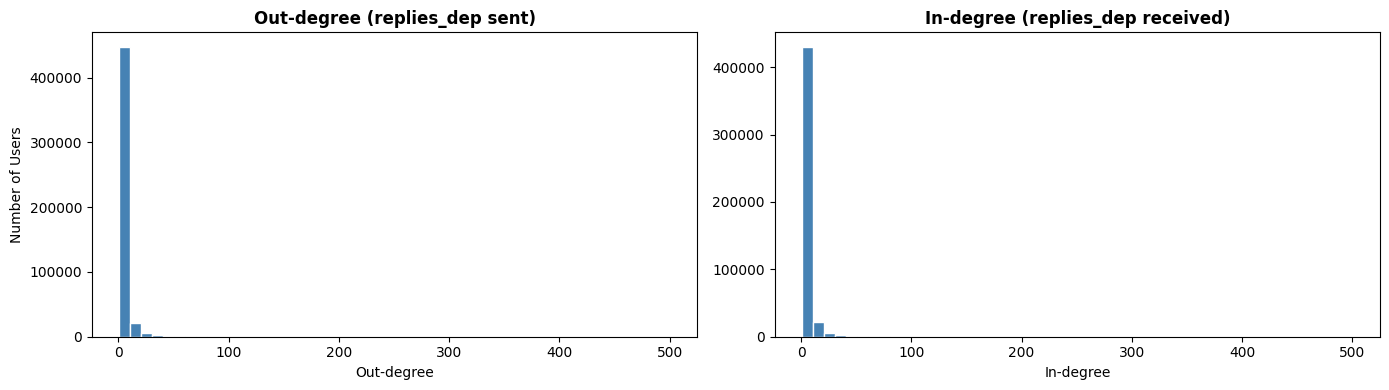

In [243]:
# in-degree and out-degree distributions
out_deg_dep = edges_dep['author'].value_counts()
in_deg_dep  = edges_dep['parent_author'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(out_deg_dep.clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Out-degree (replies_dep sent)', fontweight='bold')
axes[0].set_xlabel('Out-degree')
axes[0].set_ylabel('Number of Users')

axes[1].hist(in_deg_dep.clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('In-degree (replies_dep received)', fontweight='bold')
axes[1].set_xlabel('In-degree')

plt.tight_layout()
plt.show()

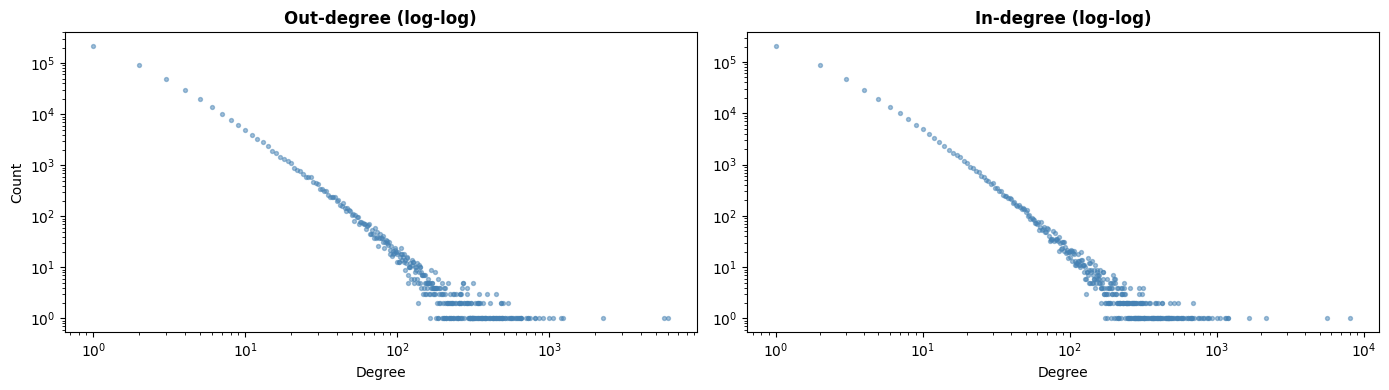

In [244]:
# log-log degree distribution (power-law check)
out_deg_counts = out_deg_dep.value_counts().sort_index()
in_deg_counts  = in_deg_dep.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(out_deg_counts.index, out_deg_counts.values, alpha=0.5, s=8, color='steelblue')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Out-degree (log-log)', fontweight='bold')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')

axes[1].scatter(in_deg_counts.index, in_deg_counts.values, alpha=0.5, s=8, color='steelblue')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('In-degree (log-log)', fontweight='bold')
axes[1].set_xlabel('Degree')

plt.tight_layout()
plt.show()

In [245]:
# basic network stats
all_users = pd.concat([edges_dep['author'], edges_dep['parent_author']])
print(f'nodes:             {all_users.nunique():,}')
print(f'edges:             {len(edges_dep):,}')
print(f'avg out-degree:    {out_deg_dep.mean():.2f}')
print(f'median out-degree: {out_deg_dep.median():.0f}')
print(f'max out-degree:    {out_deg_dep.max():,}')

nodes:             586,867
edges:             2,056,916
avg out-degree:    4.26
median out-degree: 2
max out-degree:    6,043


**Explanation:**

- **The reply network** contains 2,056,916 directed edges connecting 586,867 unique users. Each edge represents one user directly replying to another user's comment. Out of 1,234,157 qualifying users, about 47.6% appear in the reply network. This share is notably lower than in r/learnprogramming (61.4%) and r/loseit (62.3%), suggesting that in r/depression a larger proportion of users post top-level content without engaging in direct reply exchanges.

- **The out-degree distribution** (replies sent) and **in-degree distribution** (replies received) are both heavily right-skewed. The average out-degree is 4.26, but the median is only 2, indicating that most users sent very few replies while a small number of users were extremely active. The most active replier sent 6,043 replies.

- **The log-log degree distribution plots** show an approximately linear trend for both in-degree and out-degree, which is consistent with a power-law distribution. This is a common structural property of social networks and suggests that the r/depression reply network shares the same hub structure as the other two subreddits, with a small number of highly connected users and a large majority with minimal connectivity.

#### Part-7: Network Preview 2.0

r/depression — 464,233 / 1,171,362 users in network (39.6%)
  Mean out-degree    : 3.14
  Mean in-degree     : 2.86
  Mean k-core        : 2.16
  Mean clustering    : 0.0182
  Mean community size: 66929.8


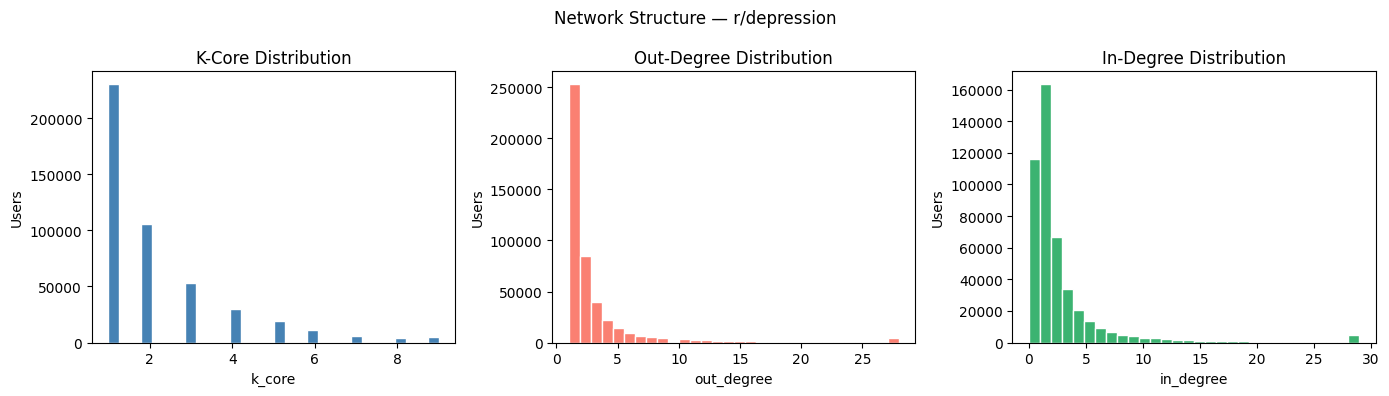

In [12]:
# Network structure — r/depression
import pandas as pd, numpy as np, matplotlib.pyplot as plt

feat   = pd.read_parquet('../data/processed_data/features_net_dep.parquet')
in_net = feat[feat['out_degree'] > 0]
pct    = len(in_net) / len(feat) * 100

print(f'r/depression — {len(in_net):,} / {len(feat):,} users in network ({pct:.1f}%)')
print(f'  Mean out-degree    : {in_net["out_degree"].mean():.2f}')
print(f'  Mean in-degree     : {in_net["in_degree"].mean():.2f}')
print(f'  Mean k-core        : {in_net["k_core"].mean():.2f}')
print(f'  Mean clustering    : {in_net["clustering_coef"].mean():.4f}')
print(f'  Mean community size: {in_net["community_size"].mean():.1f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Network Structure — r/depression', fontsize=12)

for ax, (col, title, color) in zip(axes, [
    ('k_core',     'K-Core Distribution',    'steelblue'),
    ('out_degree', 'Out-Degree Distribution', 'salmon'),
    ('in_degree',  'In-Degree Distribution',  'mediumseagreen'),
]):
    vals = in_net[col].clip(upper=in_net[col].quantile(0.99))
    ax.hist(vals, bins=30, color=color, edgecolor='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Users')
    ax.set_title(title)

plt.tight_layout()
plt.show()


## Save Cleaned Data

In [ ]:
import os
os.makedirs('../data/processed_data', exist_ok=True)

# activity records (needed for Phase 1 calibration/holdout split)
activity_lp.to_parquet('../data/processed_data/activity_lp.parquet', index=False)
activity_loseit.to_parquet('../data/processed_data/activity_loseit.parquet', index=False)
activity_dep.to_parquet('../data/processed_data/activity_dep.parquet', index=False)

# cleaned posts and comments (needed for Phase 2 NLP features)
posts_lp.to_parquet('../data/processed_data/posts_lp.parquet', index=False)
posts_loseit.to_parquet('../data/processed_data/posts_loseit.parquet', index=False)
posts_dep.to_parquet('../data/processed_data/posts_dep.parquet', index=False)

comments_lp.to_parquet('../data/processed_data/comments_lp.parquet', index=False)
comments_loseit.to_parquet('../data/processed_data/comments_loseit.parquet', index=False)
comments_dep.to_parquet('../data/processed_data/comments_dep.parquet', index=False)

# user stats (needed for Phase 2 feature engineering)
user_stats_lp.to_parquet('../data/processed_data/user_stats_lp.parquet', index=False)
user_stats_loseit.to_parquet('../data/processed_data/user_stats_loseit.parquet', index=False)
user_stats_dep.to_parquet('../data/processed_data/user_stats_dep.parquet', index=False)

# reply edge lists (needed for Phase 2 network features)
edges_lp.to_parquet('../data/processed_data/edges_lp.parquet', index=False)
edges_loseit.to_parquet('../data/processed_data/edges_loseit.parquet', index=False)
edges_dep.to_parquet('../data/processed_data/edges_dep.parquet', index=False)

print("saved to data/processed/")

saved to data/processed/


: 